In [58]:
import pandas as pd
import matplotlib.pyplot as plt

In [59]:
calender=pd.read_csv(r"Data\calendar.csv")
calender

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0


In [60]:
sellprices=pd.read_csv(r"Data/sell_prices.csv")
sellprices

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
...,...,...,...,...
6841116,WI_3,FOODS_3_827,11617,1.00
6841117,WI_3,FOODS_3_827,11618,1.00
6841118,WI_3,FOODS_3_827,11619,1.00
6841119,WI_3,FOODS_3_827,11620,1.00


In [61]:
sales=pd.read_csv(r"Data\sales_train_evaluation.csv")
sales

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30485,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,0,0,2,2,...,1,0,3,0,1,1,0,0,1,1
30486,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
30487,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,0,6,0,2,...,0,0,1,2,0,1,0,1,0,2
30488,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,1,1,1,4,6,0,1,1,1,0


In [62]:
print(sales.memory_usage(deep=True).sum() / 1024**2, "MB")

461.89601135253906 MB


In [63]:
for i in sales.columns:
    if sales[i].dtype=="int64":
        sales[i]=pd.to_numeric(sales[i],downcast="integer")
    elif sales[i].dtype=="float64":
        sales[i]=pd.to_numeric(sales[i],downcast="float")
    elif sales[i].dtype=='object':
            # convert to category IF it has repeated/limited values
            num_unique = sales[i].nunique()
            num_total = len(sales[i])
            if num_unique / num_total < 0.5:  # heuristic: repeats a lot
                sales[i] = sales[i].astype('category')
            #This matters especially for item_id (there are ~3,000 unique items but millions of rows) — as category,
            #each row just stores a small integer code instead of the full string repeated millions of times.


In [64]:
print(sales.memory_usage(deep=True).sum() / 1024**2, "MB")
# why deep==True bcz when kept false it return the meory of the pointer not the orginal size

96.89093494415283 MB


In [65]:
print("Total No.of Items across all stores ",len(sales["item_id"].unique()))

Total No.of Items across all stores  3049


In [66]:
print("Categories across all the stores ",sales["cat_id"].unique())

Categories across all the stores  ['HOBBIES', 'HOUSEHOLD', 'FOODS']
Categories (3, object): ['FOODS', 'HOBBIES', 'HOUSEHOLD']


In [67]:
print("Total No.of Stores ",len(sales["store_id"].unique()))
print(sales["store_id"].unique())

Total No.of Stores  10
['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
Categories (10, object): ['CA_1', 'CA_2', 'CA_3', 'CA_4', ..., 'TX_3', 'WI_1', 'WI_2', 'WI_3']


In [68]:
items_store={}
for i in sales["store_id"].unique():
    items_store[i]=len(sales[sales["store_id"]==i]["item_id"].unique())
items_store

{'CA_1': 3049,
 'CA_2': 3049,
 'CA_3': 3049,
 'CA_4': 3049,
 'TX_1': 3049,
 'TX_2': 3049,
 'TX_3': 3049,
 'WI_1': 3049,
 'WI_2': 3049,
 'WI_3': 3049}

In [69]:
items_category={}
for i in sales["cat_id"].unique():
    items_category[i]=len(sales[sales["cat_id"]==i]["item_id"].unique())
items_category

{'HOBBIES': 565, 'HOUSEHOLD': 1047, 'FOODS': 1437}

In [70]:
for i in items_store:
    if items_store[i]==items_store["CA_1"]:
        print("ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN ",i)
    else:
        print("ITEMS ARE DIFFRENT IN STORE CA1 AND ",i)

ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  CA_1
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  CA_2
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  CA_3
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  CA_4
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  TX_1
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  TX_2
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  TX_3
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  WI_1
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  WI_2
ALL ITEMS AVAILABLE IN STORE CA1 IS AVAILABLE IN  WI_3


In [71]:
sales.drop("id",axis=1,inplace=True)
calender.drop("weekday",axis=1,inplace=True)

In [72]:
calender[["event_name_1","event_type_1","event_name_2","event_type_2"]].isnull().sum()

event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
dtype: int64

In [73]:
calender[["event_name_1","event_type_1","event_name_2","event_type_2"]]=calender[["event_name_1","event_type_1","event_name_2","event_type_2"]].fillna("None")
calender[["event_name_1","event_type_1","event_name_2","event_type_2"]].isnull().sum()

event_name_1    0
event_type_1    0
event_name_2    0
event_type_2    0
dtype: int64

In [74]:
print(calender.memory_usage(deep=True).sum() / 1024**2, "MB")

0.718256950378418 MB


In [75]:
for i in calender.columns:
    if calender[i].dtype=="int64":
        calender[i]=pd.to_numeric(calender[i],downcast="integer")
    elif calender[i].dtype=="float64":
        calender[i]=pd.to_numeric(calender[i],downcast="float")
    elif calender[i].dtype=='object':
            num_unique = calender[i].nunique()
            num_total = len(calender[i])
            if num_unique / num_total < 0.5:  
                calender[i] = calender[i].astype('category')



In [76]:
print(calender.memory_usage(deep=True).sum() / 1024**2, "MB")


0.24149131774902344 MB


In [77]:
# 'id_vars' are the columns you want to keep 
# 'var_name' is what you want to name the new column containing the dates
# 'value_name' is what you want to name the column containing the data under those dates
sales=sales.melt(id_vars=["item_id","dept_id","cat_id","store_id","state_id"],var_name="Date",value_name="sales")
### TAKES LONG TIME
sales

,item_id,dept_id,cat_id,store_id,state_id,Date,sales
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
...,...,...,...,...,...,...,...
59181085,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1941,1
59181086,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1941,0
59181087,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1941,2
59181088,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1941,0


In [78]:
### WHY AGAIN DOWN CAST BCZ THE NEW ROWS ARE NOT ROWNCASTED AND MAY LEED TO HIGH DATASIZE SO AFTER MERGE AND MELT WE DO THE DOWN CASTING

In [79]:
print(sales.memory_usage(deep=True).sum() / 1024**2, "MB")

3523.7434282302856 MB


In [80]:
for i in sales.columns:
    if sales[i].dtype=="int64":
        sales[i]=pd.to_numeric(sales[i],downcast="integer")
    elif sales[i].dtype=="float64":
        sales[i]=pd.to_numeric(sales[i],downcast="float")
    elif sales[i].dtype=='object':
            num_unique = sales[i].nunique()
            num_total = len(sales[i])
            if num_unique / num_total < 0.5:  
                sales[i] = sales[i].astype('category')

In [81]:
print(sales.memory_usage(deep=True).sum() / 1024**2, "MB")

564.8032999038696 MB


In [82]:
sales

,item_id,dept_id,cat_id,store_id,state_id,Date,sales
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
...,...,...,...,...,...,...,...
59181085,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1941,1
59181086,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1941,0
59181087,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1941,2
59181088,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1941,0


In [83]:
dupes = sellprices.duplicated(subset=['store_id','item_id','wm_yr_wk']).sum()
print(dupes)# CHECKS WETHER WITHIN A WEEK A PRICE CHANGE HAD OCCURED
dupes = calender.duplicated(subset=["date"]).sum()
print(dupes)
dupes=sales.duplicated(subset=["item_id","Date","store_id"]).sum()
print(dupes)

0
0
0


In [84]:
sales=pd.merge(sales,calender,left_on=["Date"],right_on=["d"])
sales.drop("d",axis=1,inplace=True)
#LONG TIME

In [85]:
print(sales.memory_usage(deep=True).sum() / 1024**2, "MB")

7587.390330314636 MB


In [86]:
for i in sales.columns:
    if sales[i].dtype=="int64":
        sales[i]=pd.to_numeric(sales[i],downcast="integer")
    elif sales[i].dtype=="float64":
        sales[i]=pd.to_numeric(sales[i],downcast="float")
    elif sales[i].dtype=='object':
            # convert to category IF it has repeated/limited values
            num_unique = sales[i].nunique()
            num_total = len(sales[i])
            if num_unique / num_total < 0.5:  # heuristic: repeats a lot
                sales[i] = sales[i].astype('category')
            #This matters especially for item_id (there are ~3,000 unique items but millions of rows) — as category,
            #each row just stores a small integer code instead of the full string repeated millions of times.


In [87]:
print(sales.memory_usage(deep=True).sum() / 1024**2, "MB")
# why deep==True bcz when kept false it return the meory of the pointer not the orginal size

1411.5717658996582 MB


In [88]:
sales.drop("date",axis=1,inplace=True)
sales

,item_id,dept_id,cat_id,store_id,state_id,Date,sales,wm_yr_wk,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,11101,1,1,2011,None,None,None,None,0,0,0
1,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,11101,1,1,2011,None,None,None,None,0,0,0
2,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,11101,1,1,2011,None,None,None,None,0,0,0
3,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,11101,1,1,2011,None,None,None,None,0,0,0
4,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,11101,1,1,2011,None,None,None,None,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1941,1,11617,2,5,2016,None,None,None,None,0,0,0
59181086,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1941,0,11617,2,5,2016,None,None,None,None,0,0,0
59181087,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1941,2,11617,2,5,2016,None,None,None,None,0,0,0
59181088,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1941,0,11617,2,5,2016,None,None,None,None,0,0,0


In [89]:
sales.isnull().sum()


item_id         0
dept_id         0
cat_id          0
store_id        0
state_id        0
Date            0
sales           0
wm_yr_wk        0
wday            0
month           0
year            0
event_name_1    0
event_type_1    0
event_name_2    0
event_type_2    0
snap_CA         0
snap_TX         0
snap_WI         0
dtype: int64

In [90]:
sales=pd.merge(sellprices,sales,on=["item_id","store_id","wm_yr_wk"],how="right")
# WHY HOW=right JOINS EVERY SALES ROW IF EVEN A PRICE IS MISSING AT THAT POINT THE PRODUCTS WHICH ARE NOT AVAILABLE DURING TAHT TIME IS RECOREDED AS NAN

In [91]:
## THE INDEX CANT BE THE DATE COLUMN AS THE DATE IN THE ABOVE SALES DATA GETS REPEATED
sales

,store_id,item_id,wm_yr_wk,sell_price,dept_id,cat_id,state_id,Date,sales,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,CA_1,HOBBIES_1_001,11101,NaN,HOBBIES_1,HOBBIES,CA,d_1,0,1,1,2011,None,None,None,None,0,0,0
1,CA_1,HOBBIES_1_002,11101,NaN,HOBBIES_1,HOBBIES,CA,d_1,0,1,1,2011,None,None,None,None,0,0,0
2,CA_1,HOBBIES_1_003,11101,NaN,HOBBIES_1,HOBBIES,CA,d_1,0,1,1,2011,None,None,None,None,0,0,0
3,CA_1,HOBBIES_1_004,11101,NaN,HOBBIES_1,HOBBIES,CA,d_1,0,1,1,2011,None,None,None,None,0,0,0
4,CA_1,HOBBIES_1_005,11101,NaN,HOBBIES_1,HOBBIES,CA,d_1,0,1,1,2011,None,None,None,None,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,WI_3,FOODS_3_823,11617,2.98,FOODS_3,FOODS,WI,d_1941,1,2,5,2016,None,None,None,None,0,0,0
59181086,WI_3,FOODS_3_824,11617,2.48,FOODS_3,FOODS,WI,d_1941,0,2,5,2016,None,None,None,None,0,0,0
59181087,WI_3,FOODS_3_825,11617,3.98,FOODS_3,FOODS,WI,d_1941,2,2,5,2016,None,None,None,None,0,0,0
59181088,WI_3,FOODS_3_826,11617,1.28,FOODS_3,FOODS,WI,d_1941,0,2,5,2016,None,None,None,None,0,0,0


In [92]:
print(sales.memory_usage(deep=True).sum() / 1024**2, "MB")

8395.213940620422 MB


In [93]:
for i in sales.columns:
    if sales[i].dtype=="int64":
        sales[i]=pd.to_numeric(sales[i],downcast="integer")
    elif sales[i].dtype=="float64":
        sales[i]=pd.to_numeric(sales[i],downcast="float")
    elif sales[i].dtype=='object':
            num_unique = sales[i].nunique()
            num_total = len(sales[i])
            if num_unique / num_total < 0.5:  
                sales[i] = sales[i].astype('category')

In [94]:
print(sales.memory_usage(deep=True).sum() / 1024**2, "MB")

1524.2784967422485 MB


In [95]:
# After merging, check how many rows have missing price
# Filter out rows before the item's first recorded price (item wasn't sellable yet)
#.cumsum will work only on sorted values but works here bcz the values is set to nan
# `awhich is the top untill it is introduced so which is already at top when handleing the new launch product

newlaunch = sales["sell_price"].notna().groupby([sales["item_id"], sales["store_id"]]).cumsum() > 0
sales=sales[newlaunch]
sales

C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\1331029493.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  newlaunch = sales["sell_price"].notna().groupby([sales["item_id"], sales["store_id"]]).cumsum() > 0


,store_id,item_id,wm_yr_wk,sell_price,dept_id,cat_id,state_id,Date,sales,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
7,CA_1,HOBBIES_1_008,11101,0.46,HOBBIES_1,HOBBIES,CA,d_1,12,1,1,2011,None,None,None,None,0,0,0
8,CA_1,HOBBIES_1_009,11101,1.56,HOBBIES_1,HOBBIES,CA,d_1,2,1,1,2011,None,None,None,None,0,0,0
9,CA_1,HOBBIES_1_010,11101,3.17,HOBBIES_1,HOBBIES,CA,d_1,0,1,1,2011,None,None,None,None,0,0,0
11,CA_1,HOBBIES_1_012,11101,5.98,HOBBIES_1,HOBBIES,CA,d_1,0,1,1,2011,None,None,None,None,0,0,0
14,CA_1,HOBBIES_1_015,11101,0.70,HOBBIES_1,HOBBIES,CA,d_1,4,1,1,2011,None,None,None,None,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,WI_3,FOODS_3_823,11617,2.98,FOODS_3,FOODS,WI,d_1941,1,2,5,2016,None,None,None,None,0,0,0
59181086,WI_3,FOODS_3_824,11617,2.48,FOODS_3,FOODS,WI,d_1941,0,2,5,2016,None,None,None,None,0,0,0
59181087,WI_3,FOODS_3_825,11617,3.98,FOODS_3,FOODS,WI,d_1941,2,2,5,2016,None,None,None,None,0,0,0
59181088,WI_3,FOODS_3_826,11617,1.28,FOODS_3,FOODS,WI,d_1941,0,2,5,2016,None,None,None,None,0,0,0


In [96]:
sales["sell_price"].isnull().sum() ### NO OUT OF STOCK IN BETWEEN THE TIMELINE ONCE LAUNCED  THE DATA IS NOT NAN UNTILL THE END OF THE PERIOD

np.int64(0)

In [97]:
print("NO.of ITEM ",len(sales["item_id"].unique()))
print("NO.of DEPARTMENT",len(sales["dept_id"].unique()))
print("NO.OF CATEGORIES",len(sales["cat_id"].unique()))

NO.of ITEM  3049
NO.of DEPARTMENT 7
NO.OF CATEGORIES 3


In [98]:
print(sales.memory_usage(deep=True).sum() / 1024**2, "MB")

1565.2570552825928 MB


In [99]:
for i in sales.columns:
    if sales[i].dtype=="int64":
        sales[i]=pd.to_numeric(sales[i],downcast="integer")
    elif sales[i].dtype=="float64":
        sales[i]=pd.to_numeric(sales[i],downcast="float")
    elif sales[i].dtype=='object':
            num_unique = sales[i].nunique()
            num_total = len(sales[i])
            if num_unique / num_total < 0.5:  
                sales[i] = sales[i].astype('category')



In [100]:
print(sales.memory_usage(deep=True).sum() / 1024**2, "MB")

1565.2570552825928 MB


In [101]:
weekdays=sales.groupby(["wday","store_id"])["sales"].mean()
weekdays.unstack()

C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\647972972.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekdays=sales.groupby(["wday","store_id"])["sales"].mean()


store_id,CA_1,CA_2,CA_3,CA_4,TX_1,TX_2,TX_3,WI_1,WI_2,WI_3
wday,,,,,,,,,,
1,2.057239,1.787298,2.743599,1.003173,1.398917,1.818270,1.510904,1.559140,1.672405,1.684745
2,2.084118,1.708786,2.873848,1.030477,1.484283,1.868175,1.554276,1.345229,1.522638,1.580728
3,1.567289,1.176379,2.404278,0.913325,1.138529,1.479073,1.310767,0.990328,1.363194,1.279137
4,1.386968,1.099638,2.197822,0.838691,1.048839,1.327327,1.185062,0.962064,1.331823,1.219331
5,1.350030,1.097767,2.123139,0.813628,1.045148,1.327964,1.160073,0.990703,1.348598,1.190603
6,1.365567,1.125140,2.098336,0.816145,1.048243,1.347360,1.165473,1.000026,1.351241,1.210329
7,1.634924,1.339936,2.275731,0.876304,1.139341,1.500539,1.281808,1.225226,1.499078,1.429913


<Axes: xlabel='store_id', ylabel='wday'>

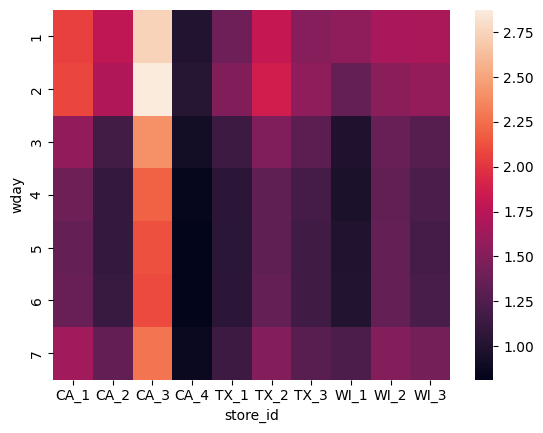

In [102]:
import seaborn as sns
sns.heatmap(weekdays.unstack())

In [103]:
## FIGURE INDICATES THAT THE CA_4 HAS LOW SALES AS IT HAS VALUES RANGING FROM 0 to 1.25
## HIGH SALES FOUND IN THE CA_3 RANGING FROM 1.75-2.75

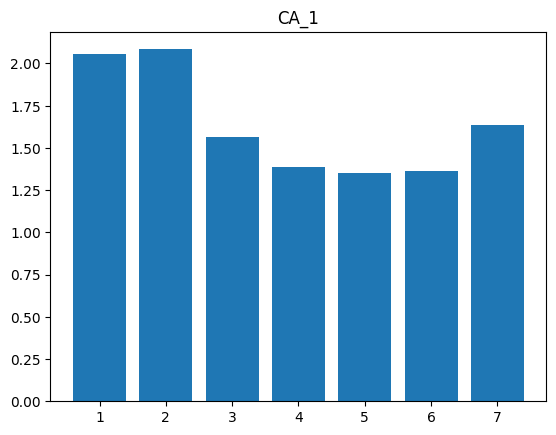

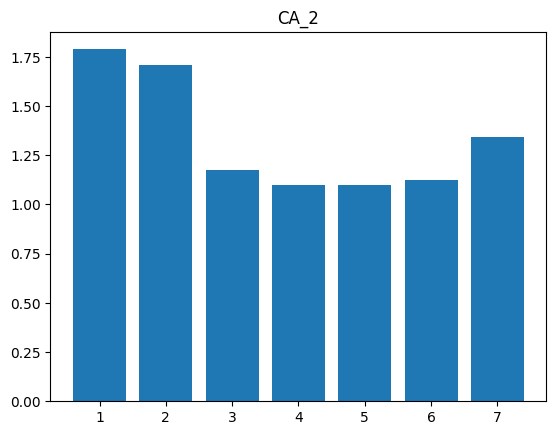

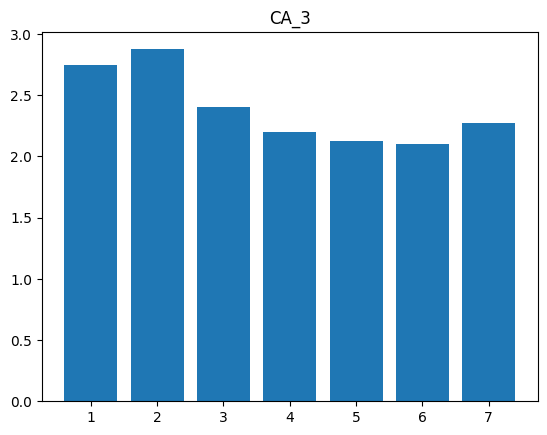

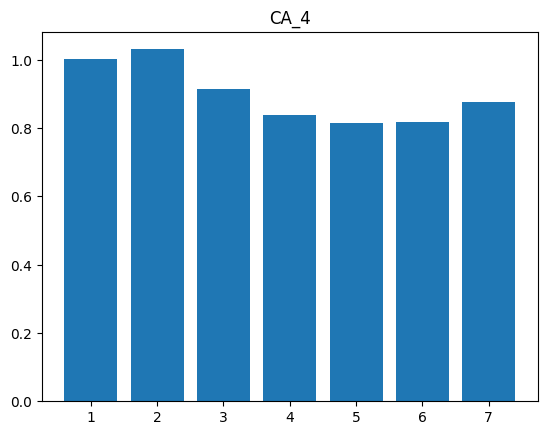

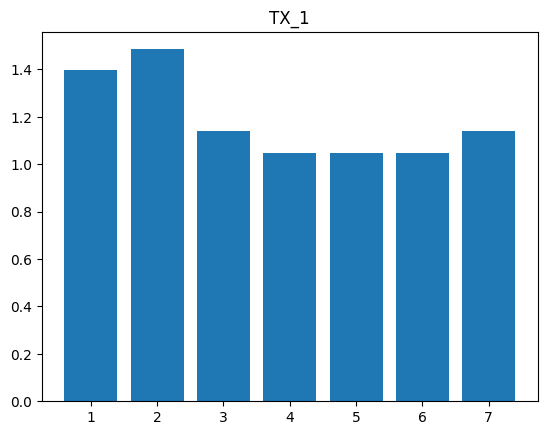

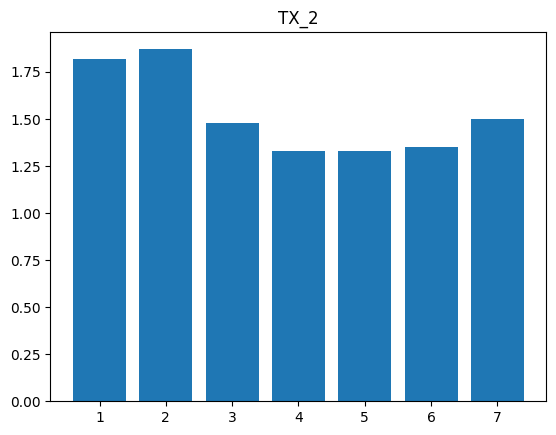

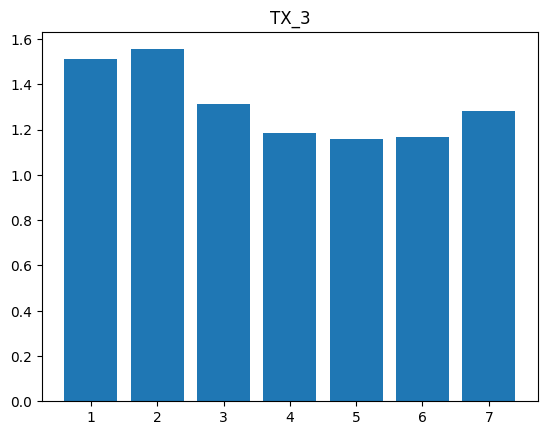

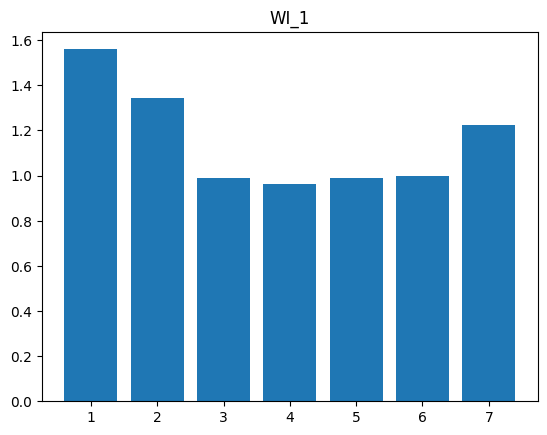

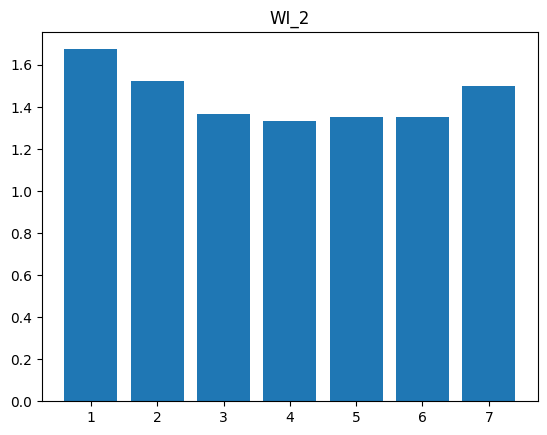

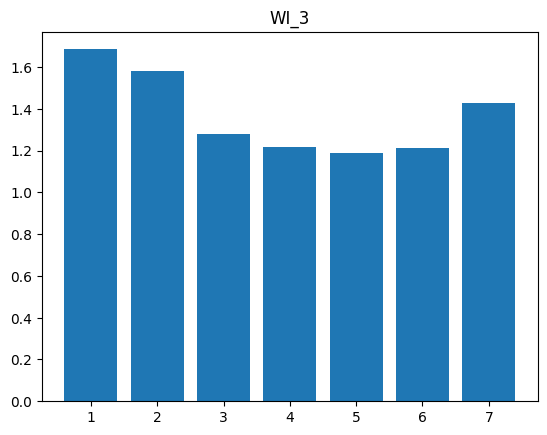

In [104]:
import seaborn as sns
for i in weekdays.unstack().columns:
    x=weekdays.unstack()[i]
    plt.bar(x.index,x.values)
    plt.title(i)
    plt.show()
### THE GRAPH SUGGEST  THAT THERE IS SIGNIFICANT DIFFRENCE IN THE SALES AT DIFF DAYS SO MEAN ENCODING


In [105]:
sales["wday_enc"]=sales.groupby(["wday","store_id"])["sales"].transform("mean")
sales.drop("wday",axis=1,inplace=True)
sales
## WHY NOT THE ENCODING OVERALL IRRESPECTIVE OF THE STOREID AS THE GRAPH SUGGESTS THAT THE VIEW CA2,CA1 GRAPH THE DIP IN MONDAY SALES COMPARED TO INCREASE IN OTHER
### ALSO MEAN ENCODING WHEN DONE IN GROUP HELPS US TO CAPTURE LOT OF HIDDEN PATTERNS

C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\634575381.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales["wday_enc"]=sales.groupby(["wday","store_id"])["sales"].transform("mean")
C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\634575381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales["wday_enc"]=sales.groupby(["wday","store_id"])["sales"].transform("mean")
C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\634575381.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the

,store_id,item_id,wm_yr_wk,sell_price,dept_id,cat_id,state_id,Date,sales,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,wday_enc
7,CA_1,HOBBIES_1_008,11101,0.46,HOBBIES_1,HOBBIES,CA,d_1,12,1,2011,None,None,None,None,0,0,0,2.057239
8,CA_1,HOBBIES_1_009,11101,1.56,HOBBIES_1,HOBBIES,CA,d_1,2,1,2011,None,None,None,None,0,0,0,2.057239
9,CA_1,HOBBIES_1_010,11101,3.17,HOBBIES_1,HOBBIES,CA,d_1,0,1,2011,None,None,None,None,0,0,0,2.057239
11,CA_1,HOBBIES_1_012,11101,5.98,HOBBIES_1,HOBBIES,CA,d_1,0,1,2011,None,None,None,None,0,0,0,2.057239
14,CA_1,HOBBIES_1_015,11101,0.70,HOBBIES_1,HOBBIES,CA,d_1,4,1,2011,None,None,None,None,0,0,0,2.057239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,WI_3,FOODS_3_823,11617,2.98,FOODS_3,FOODS,WI,d_1941,1,5,2016,None,None,None,None,0,0,0,1.580728
59181086,WI_3,FOODS_3_824,11617,2.48,FOODS_3,FOODS,WI,d_1941,0,5,2016,None,None,None,None,0,0,0,1.580728
59181087,WI_3,FOODS_3_825,11617,3.98,FOODS_3,FOODS,WI,d_1941,2,5,2016,None,None,None,None,0,0,0,1.580728
59181088,WI_3,FOODS_3_826,11617,1.28,FOODS_3,FOODS,WI,d_1941,0,5,2016,None,None,None,None,0,0,0,1.580728


C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\1488058304.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x=sales.groupby([i,"store_id"])["sales"].mean().unstack() ##THE MEAN IS USED HERE AS THE NO.OF OCCURANCES OF NONE IS HIGH AND CAN OVERCOME OTHERS WHEN .sum IS USED


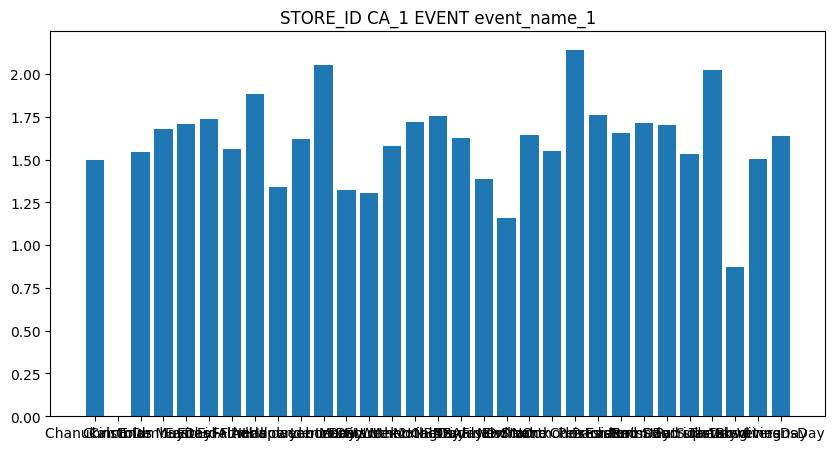

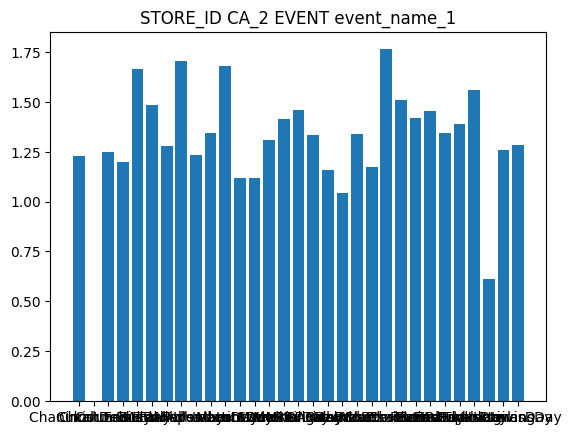

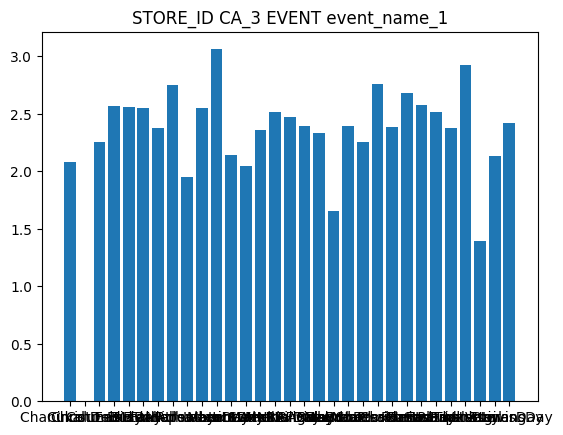

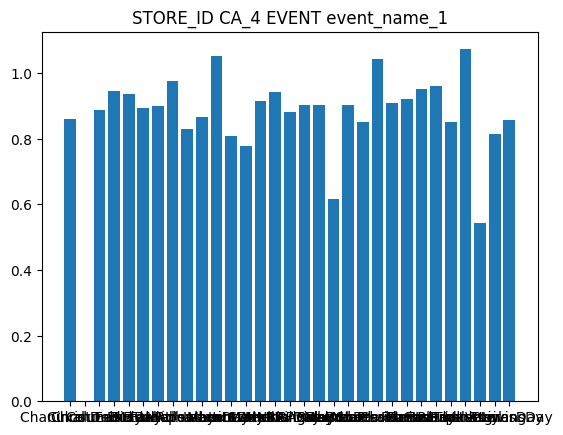

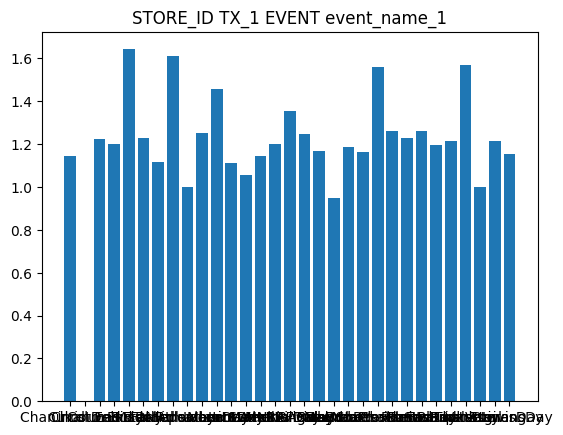

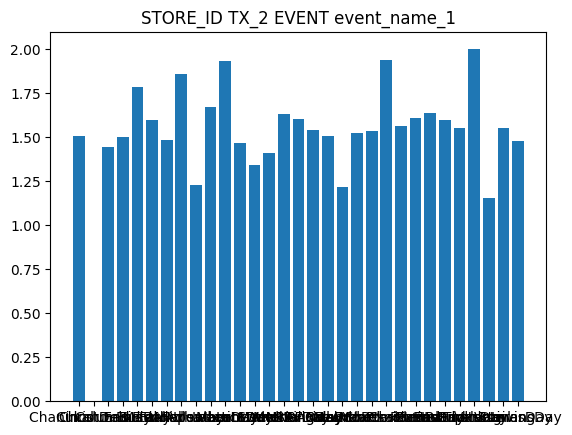

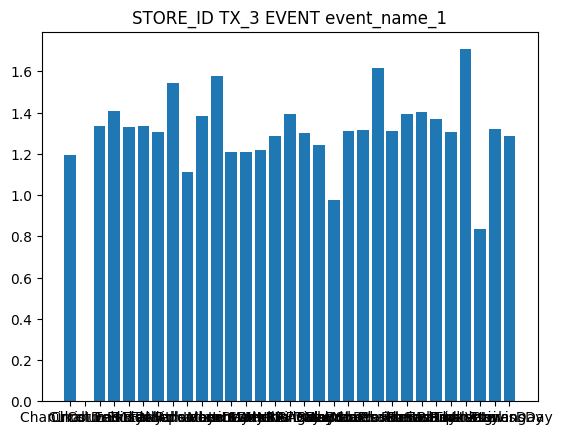

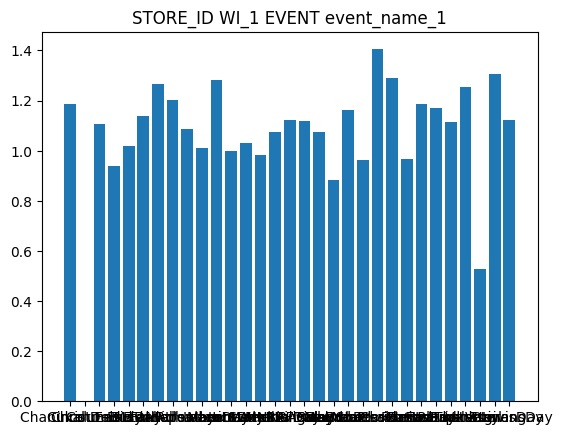

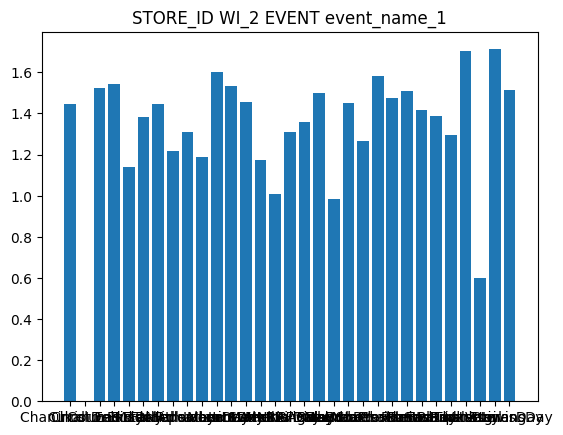

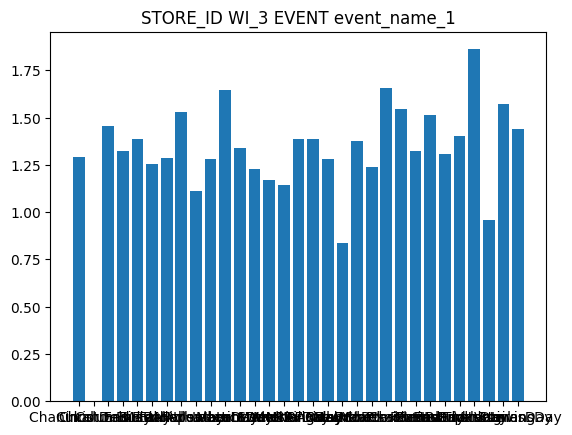

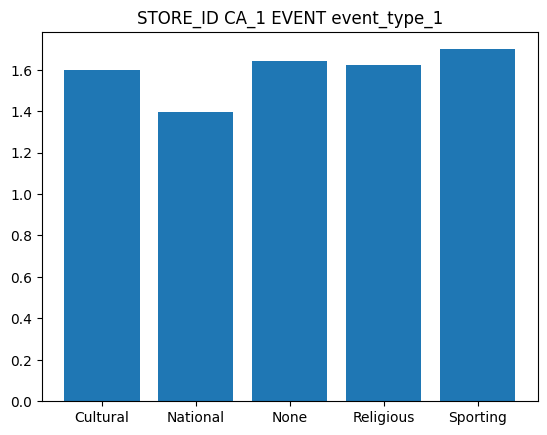

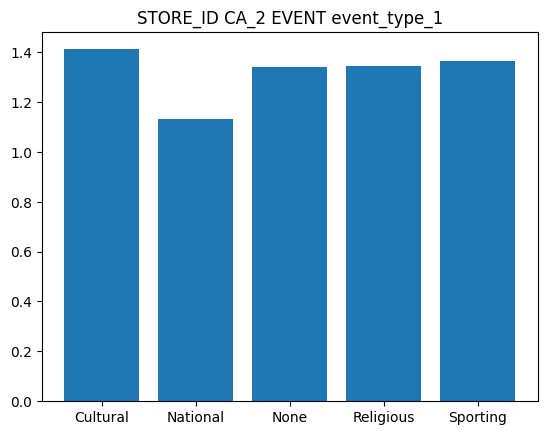

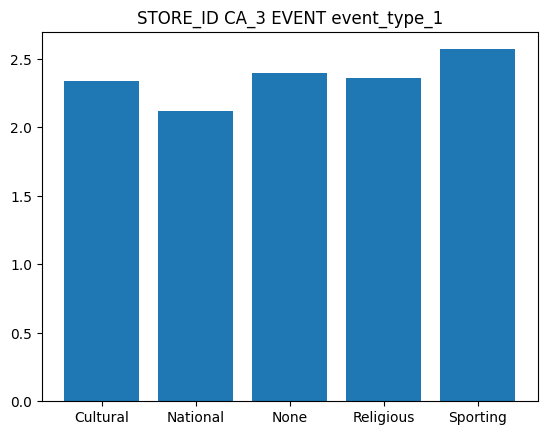

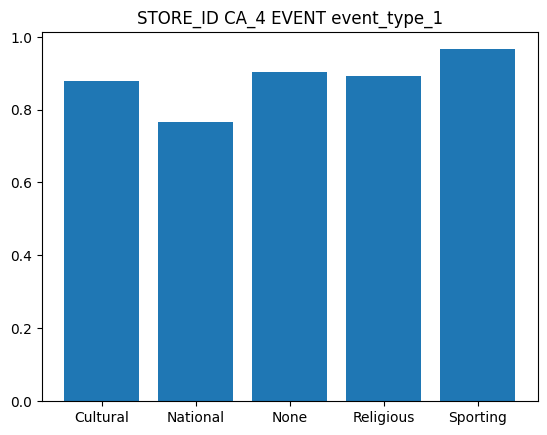

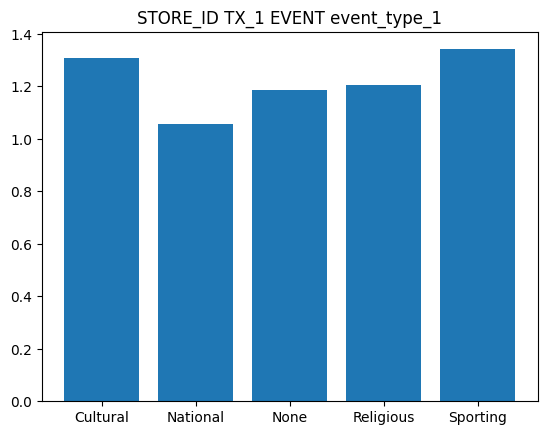

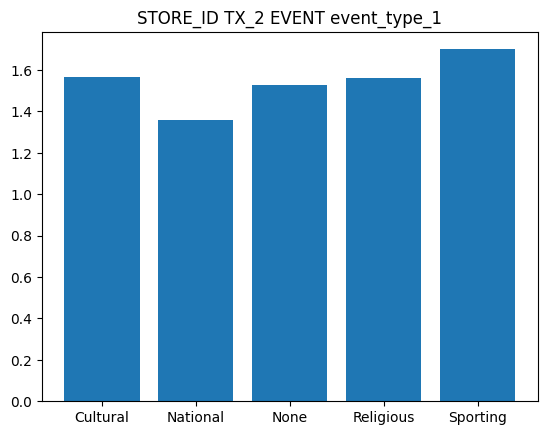

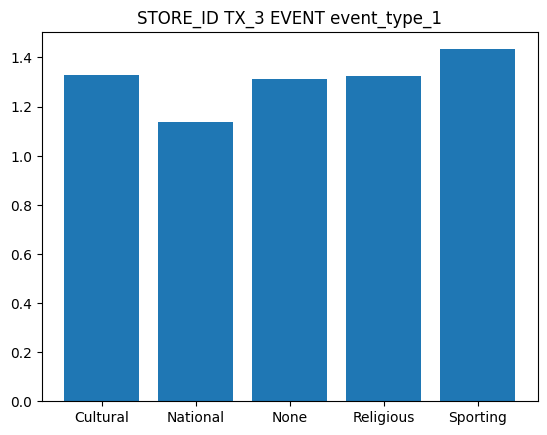

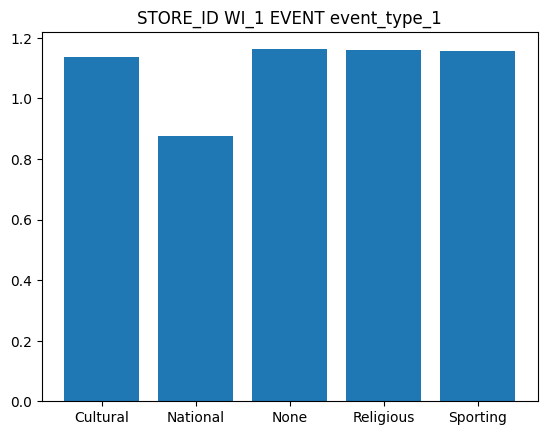

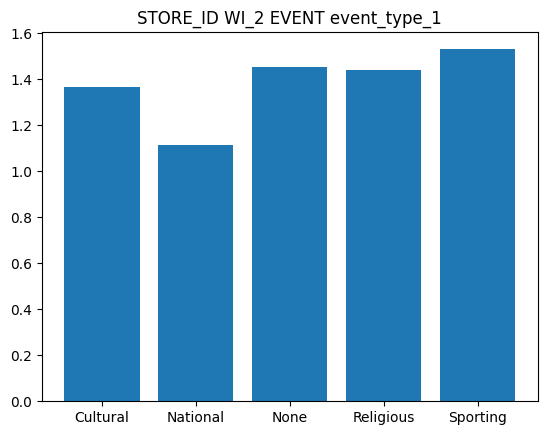

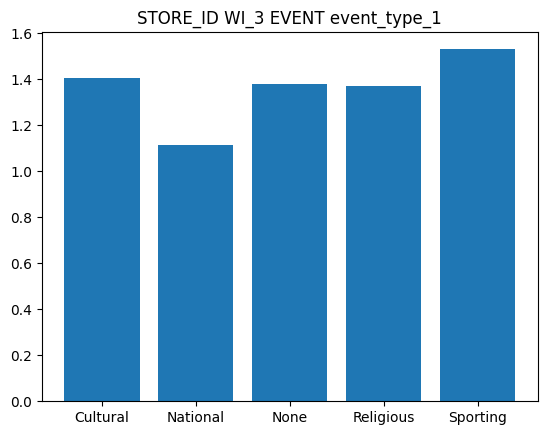

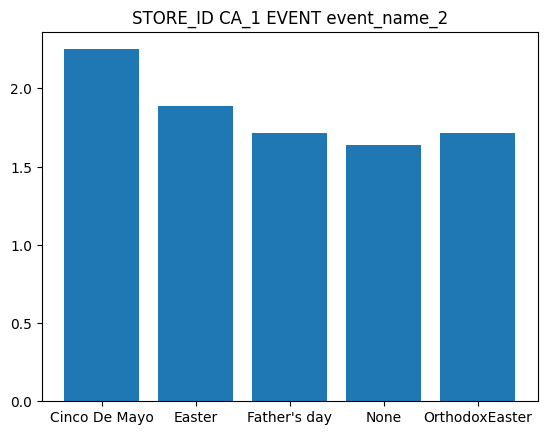

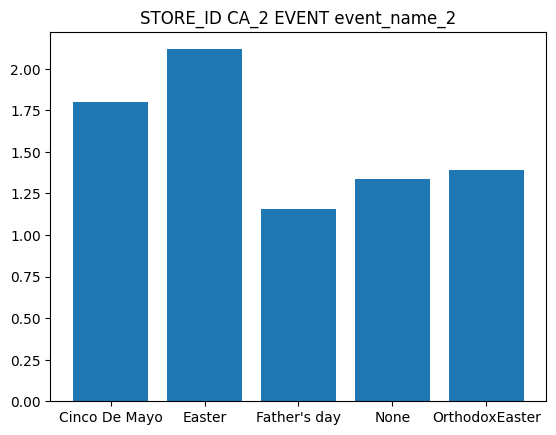

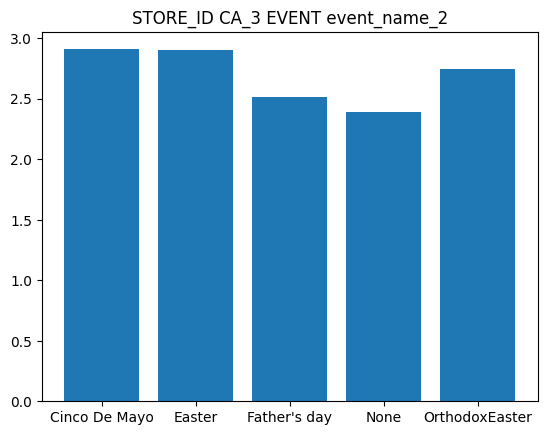

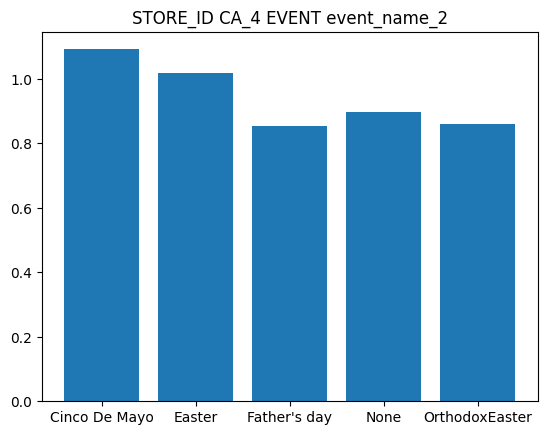

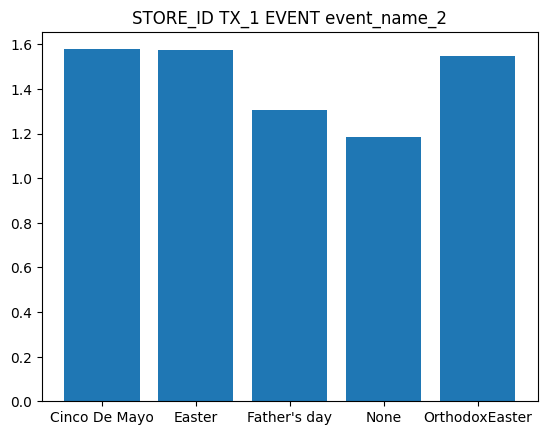

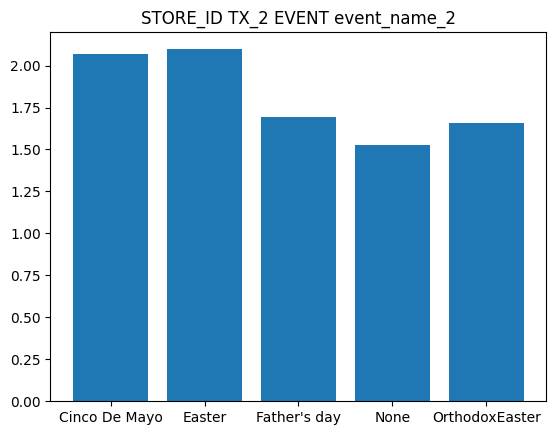

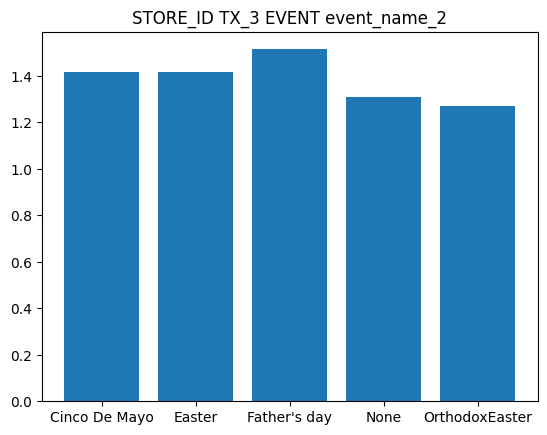

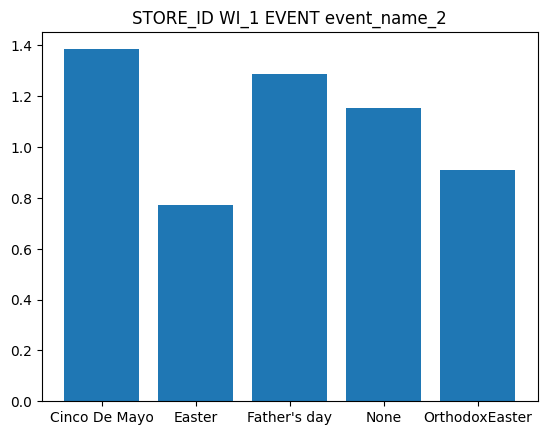

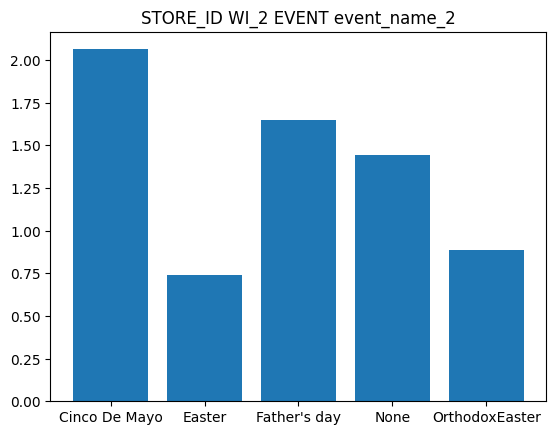

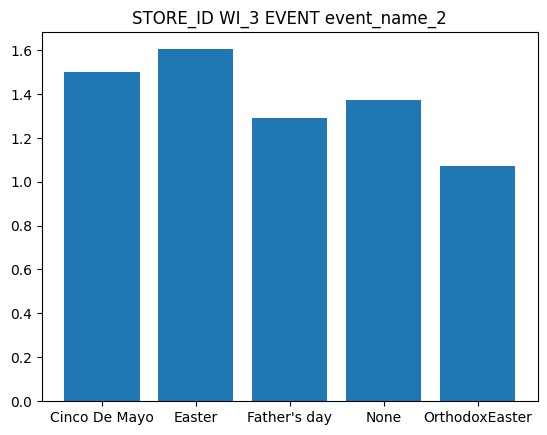

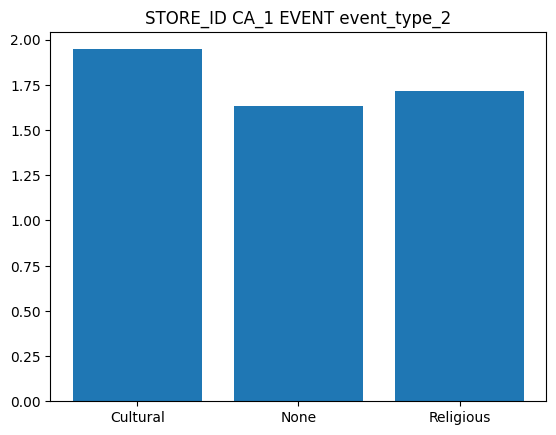

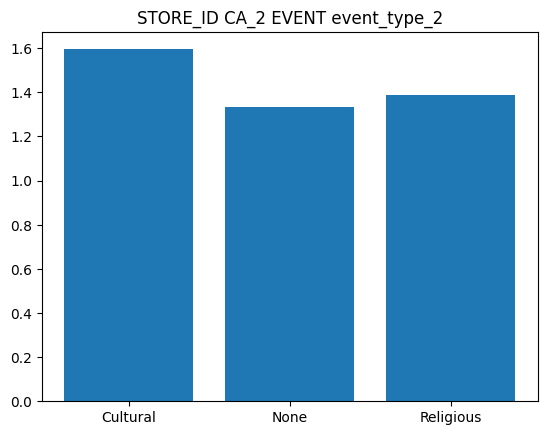

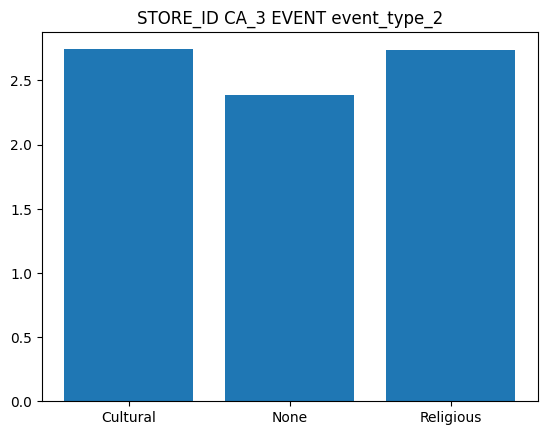

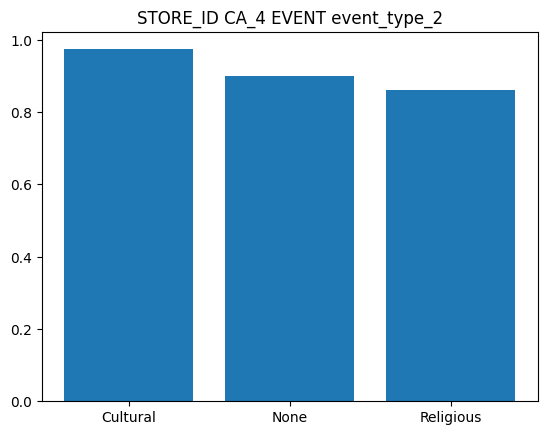

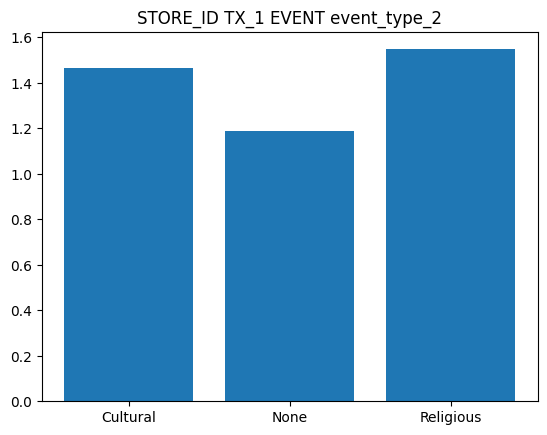

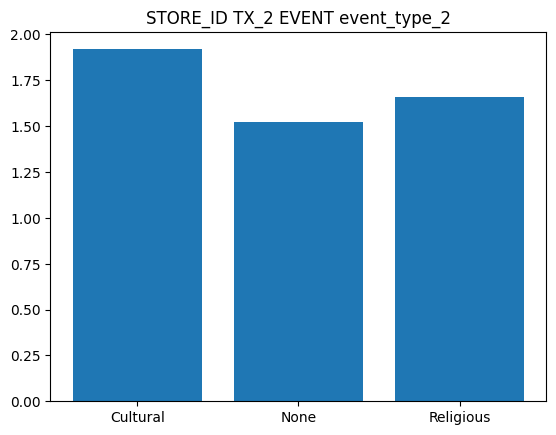

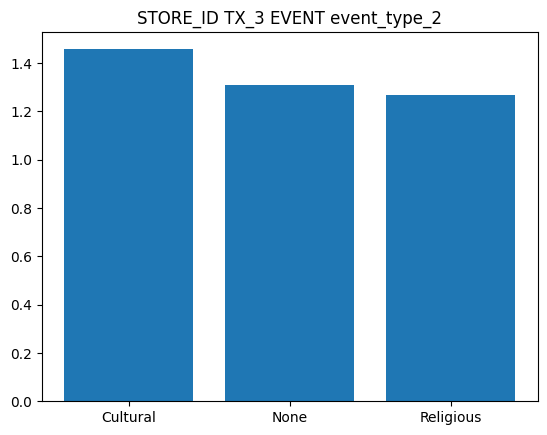

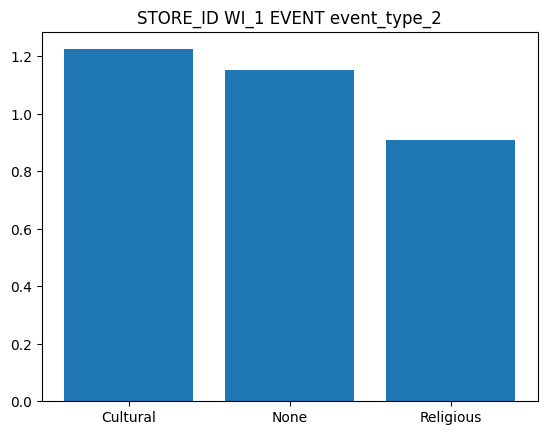

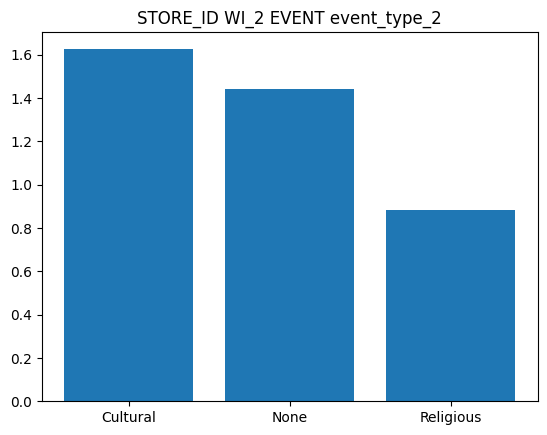

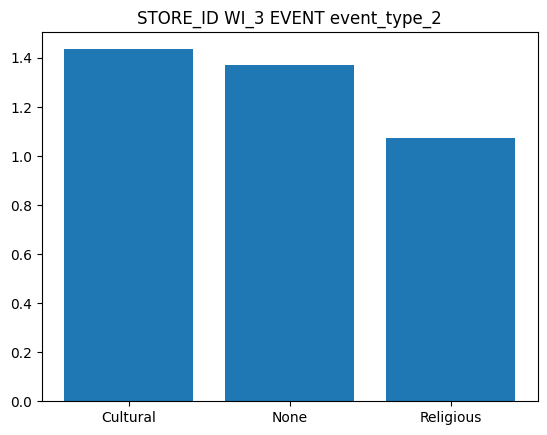

In [106]:
events=["event_name_1","event_type_1","event_name_2","event_type_2"]
plt.figure(figsize=(10,5))

for i in events:
    x=sales.groupby([i,"store_id"])["sales"].mean().unstack() ##THE MEAN IS USED HERE AS THE NO.OF OCCURANCES OF NONE IS HIGH AND CAN OVERCOME OTHERS WHEN .sum IS USED
    for j in x.columns:
        plt.bar(x.index,x[j])
        plt.title("STORE_ID "+j+" EVENT "+i)
        plt.show()


In [107]:
### NOTE  IN THE GRPAH THAT THERE IS AN NO SIGNIFICATNT DIFFFERENCE IN THE GRAPHS OF ENENT TYPE 1 SO WE ONLY DO MEAN ENCODING FOR OTHER THREE EVENT FEATURES BASED ON STORE
## THE LESSER THE NO.oF OCUURANCE OF THE EVENT WILL MAKE TO CAPTURE NOISE AND OVERFIT
### HAS SIGNIFIACENT NUMBER OF VALUES SAY MORE THAN 300 ROWS AND LETES DO MEAN ENCODING FOR IT CHECKED BY.count() I CONSIDERED AT LESEAT ONE PERCENT
events=["event_name_1","event_type_1","event_name_2","event_type_2"]
sales["event_name_1_enc"]=sales.groupby(["event_name_1","store_id"])["sales"].transform("mean")
sales["event_name_2_enc"]=sales.groupby(["event_name_2","store_id"])["sales"].transform("mean")
sales["event_type_2_enc"]=sales.groupby(["event_type_2","store_id"])["sales"].transform("mean")
sales.drop(events,axis=1,inplace=True)

C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\480067645.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales["event_name_1_enc"]=sales.groupby(["event_name_1","store_id"])["sales"].transform("mean")
C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\480067645.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales["event_name_1_enc"]=sales.groupby(["event_name_1","store_id"])["sales"].transform("mean")
C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\480067645.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to 

C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\1061488632.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dept_sales = sales.groupby("dept_id")["sales"].sum() ##DEPT_SALES IS AN SERIES WITH INDEX NAMES OF DEPT AND VALUES  AS SALES


<BarContainer object of 7 artists>

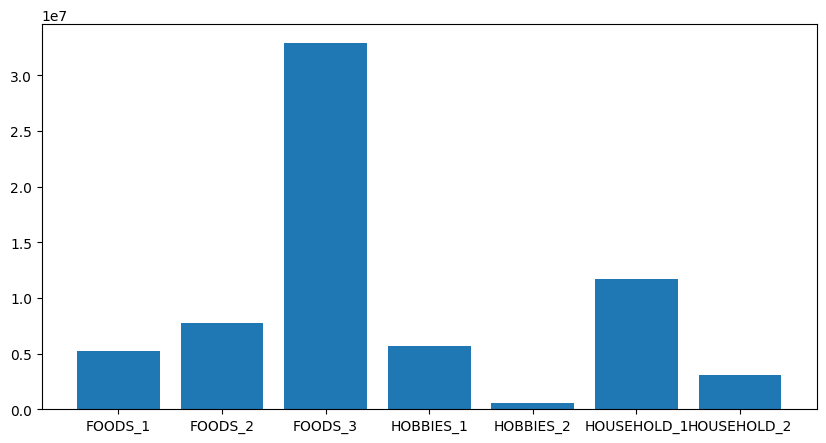

In [114]:
dept_sales = sales.groupby("dept_id")["sales"].sum() ##DEPT_SALES IS AN SERIES WITH INDEX NAMES OF DEPT AND VALUES  AS SALES
plt.figure(figsize=(10,5))
plt.bar(dept_sales.index,dept_sales.values)


C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\4273940601.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dept_sales = sales.groupby("store_id")["sales"].sum() ## THE OTHER STARES APPEARS EVVEN THOUGH I GAVE ONLY ONE STATE BCZ OF THE LOOK UP TABLE CREATE PREVIOUSLY


<BarContainer object of 10 artists>

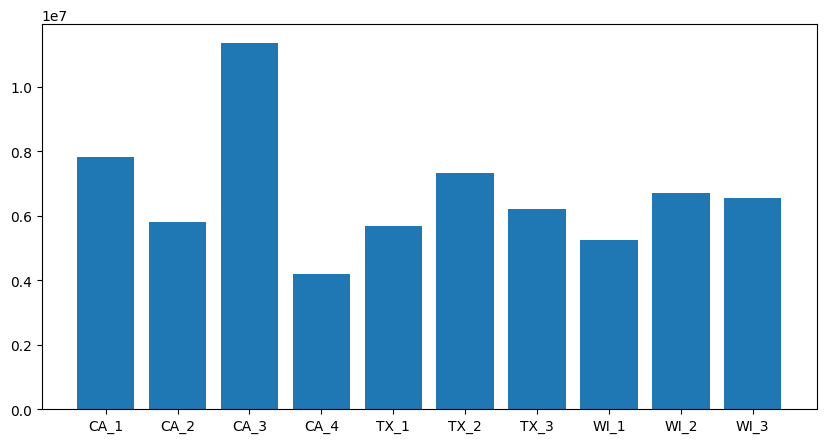

In [115]:
dept_sales = sales.groupby("store_id")["sales"].sum() ## THE OTHER STARES APPEARS EVVEN THOUGH I GAVE ONLY ONE STATE BCZ OF THE LOOK UP TABLE CREATE PREVIOUSLY
plt.figure(figsize=(10,5))
plt.bar(dept_sales.index,dept_sales.values)


In [110]:
# THE VARIATION IN THE ABOVVE GRAPHS ARE VERY HUGE SO USING THE MEAN ENCODING

C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\2130679230.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dept_sales = sales.groupby(["cat_id","store_id"])["sales"].mean().unstack() ##DEPT_SALES IS AN SERIES WITH INDEX NAMES OF DEPT AND VALUES  AS SALES


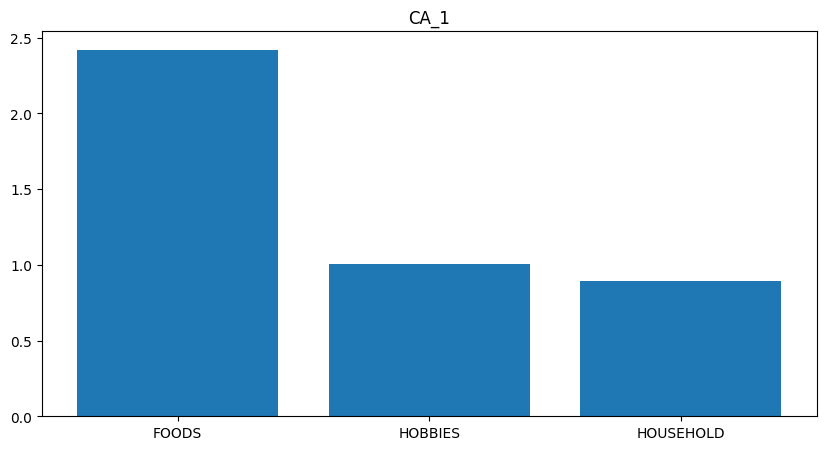

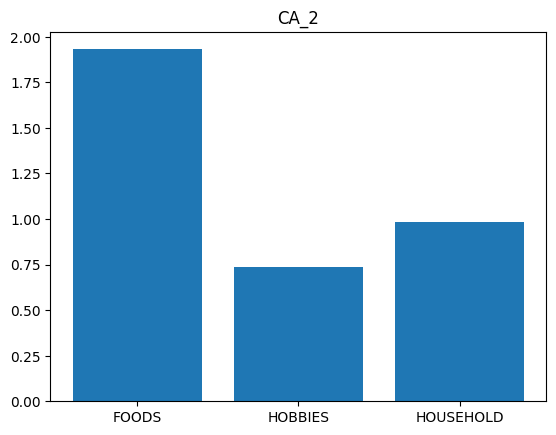

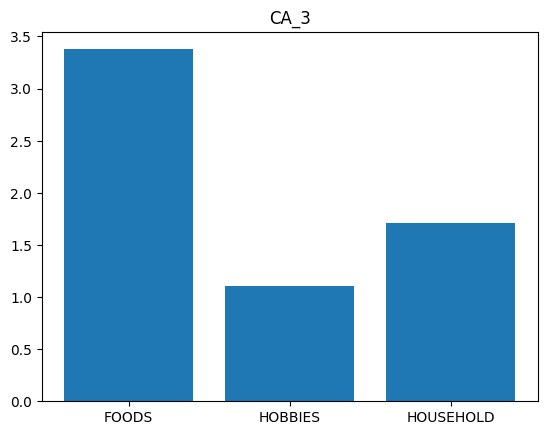

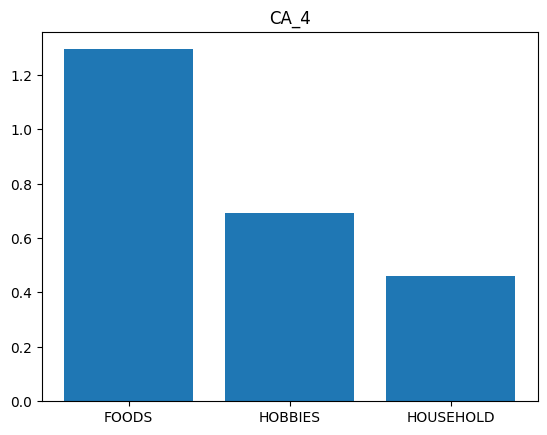

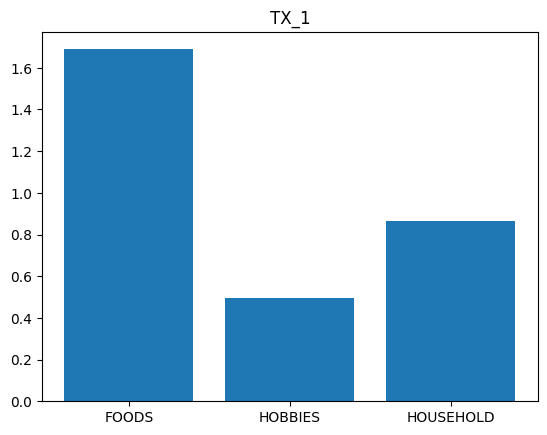

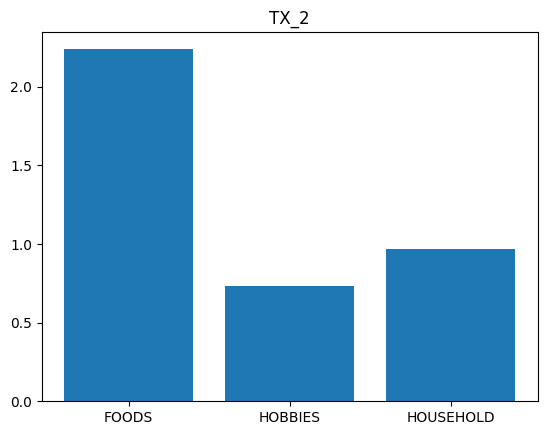

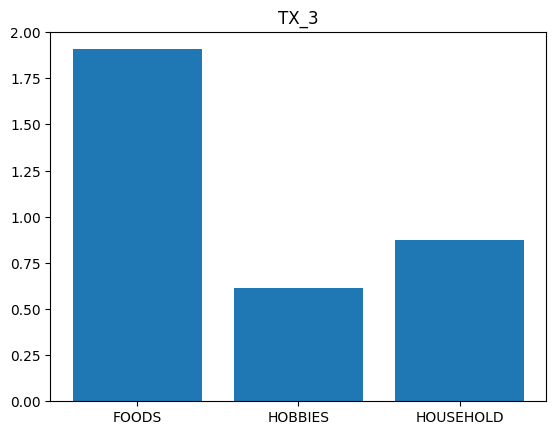

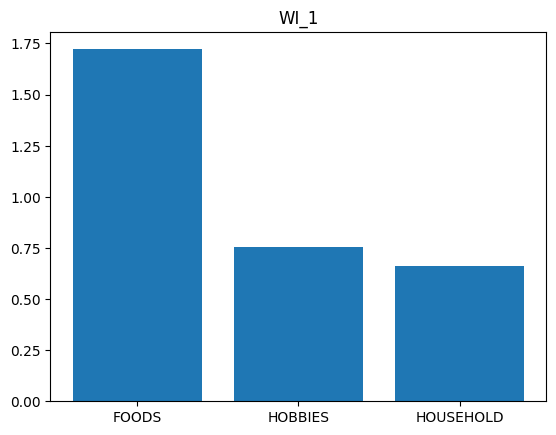

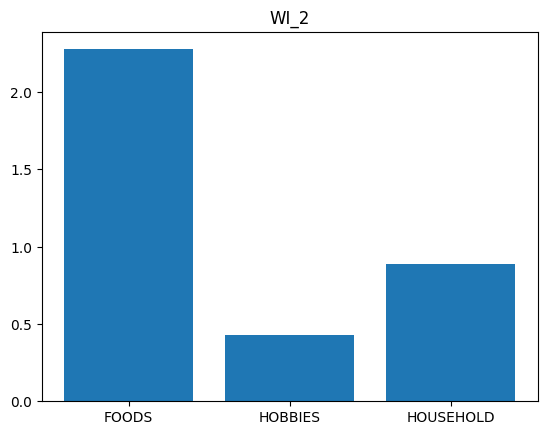

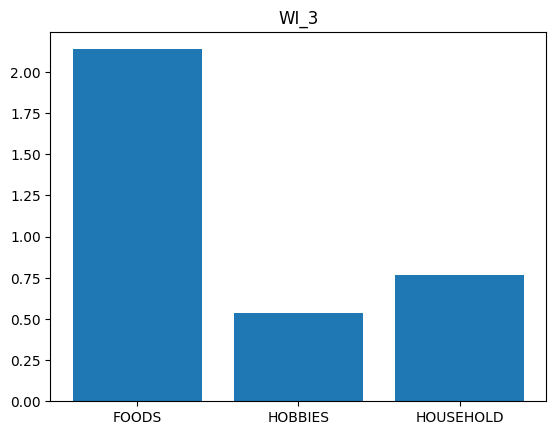

In [111]:
dept_sales = sales.groupby(["cat_id","store_id"])["sales"].mean().unstack() ##DEPT_SALES IS AN SERIES WITH INDEX NAMES OF DEPT AND VALUES  AS SALES
plt.figure(figsize=(10,5))
for i in dept_sales.columns:
    plt.title(i)
    plt.bar(dept_sales[i].index,dept_sales[i].values)
    plt.show()

In [112]:
## IN EACH STORE WE COOULD FIND THE DIFF DEPARTMENT CONTRIBUTE 
# IN DIFF RATIO TO THE THE SALES AND IN OVERALL CONSEDRATION THE FOODS HAVE QUIET MORE CONTRIBUTOIN 

In [113]:
### AS THE PLOT HAS DIFFRENT VALUES FOR DIFF CATEGORY AND DIFF DEPARTMENT WE DO MEAN ENCODING
"""
.mean() shrinks your data down to one row per group.

.transform("mean") keeps your data the exact same size, broadcasting the group's answer back to every individual row"""

'\n.mean() shrinks your data down to one row per group.\n\n.transform("mean") keeps your data the exact same size, broadcasting the group\'s answer back to every individual row'

C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\2166988296.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x=sales.groupby(["year","store_id"])["sales"].mean().unstack()


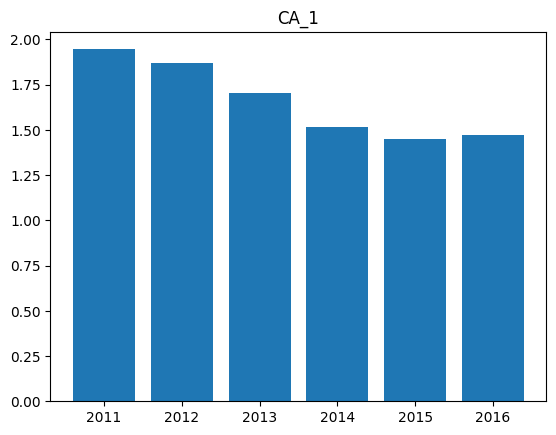

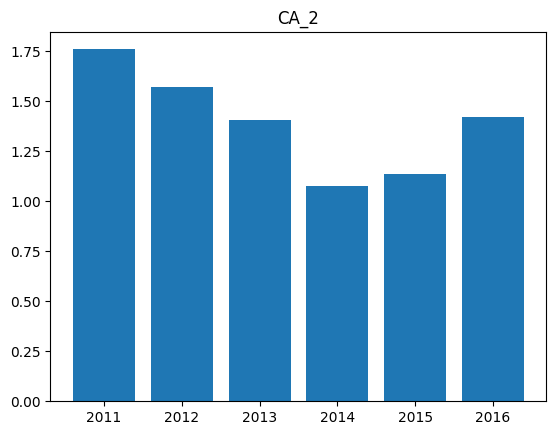

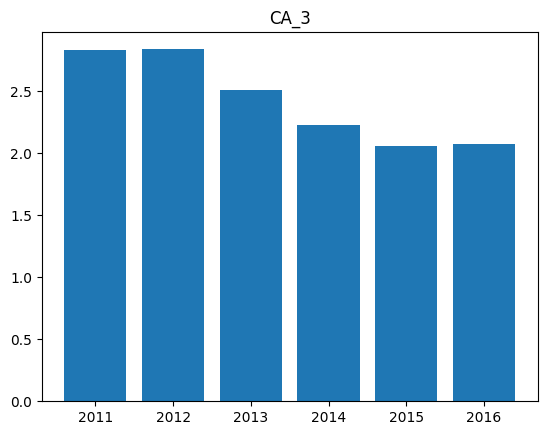

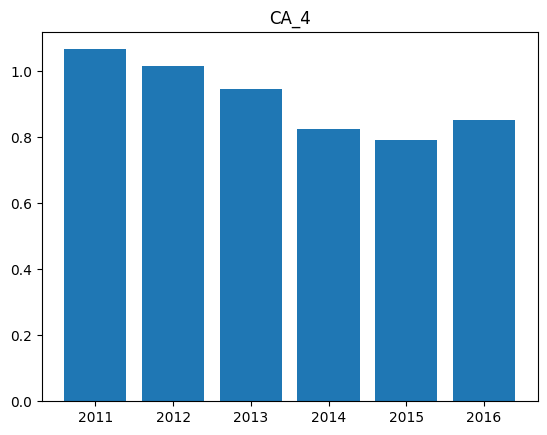

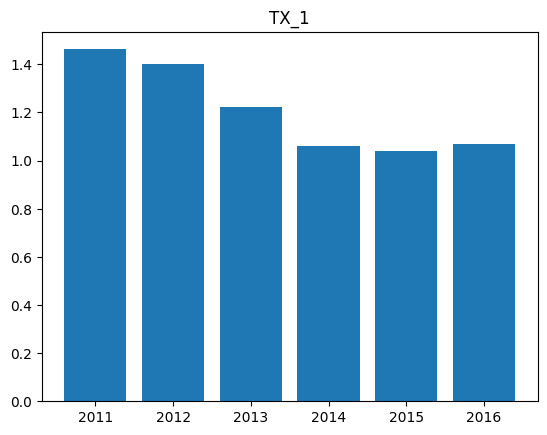

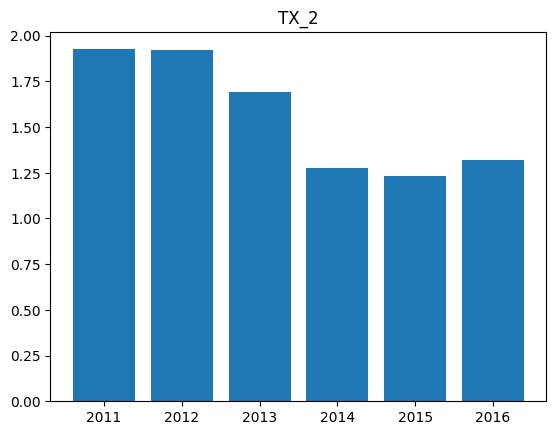

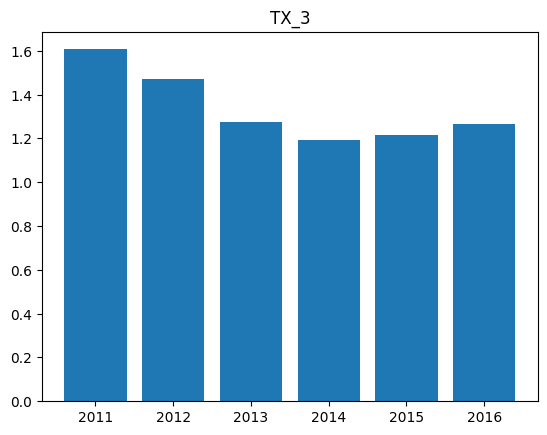

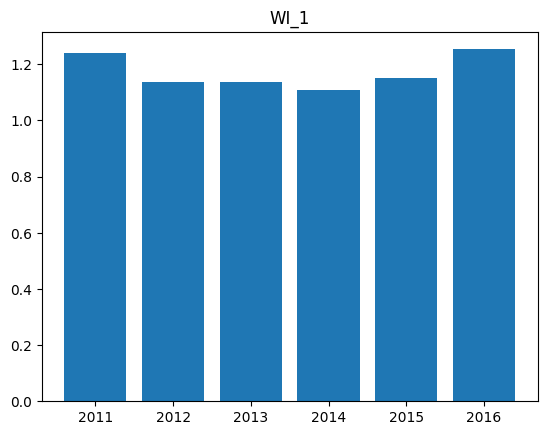

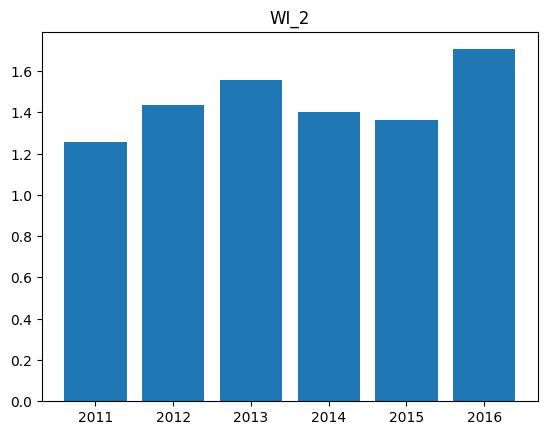

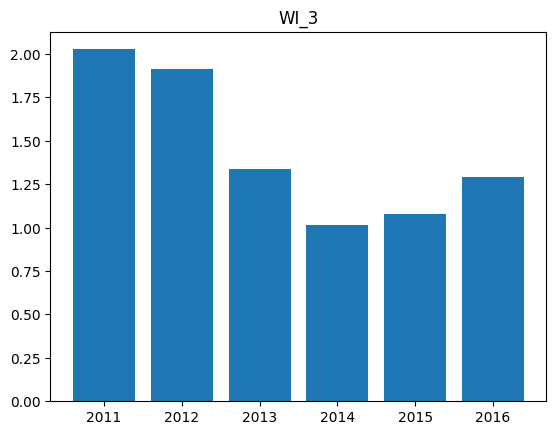

C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\2166988296.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales["year_enc"]=sales.groupby(["year","store_id"])["sales"].transform("mean")
C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\2166988296.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales["year_enc"]=sales.groupby(["year","store_id"])["sales"].transform("mean")
C:\Users\Shree\AppData\Local\Temp\ipykernel_19188\2166988296.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in 

,store_id,item_id,wm_yr_wk,sell_price,dept_id,cat_id,state_id,Date,sales,month,snap_CA,snap_TX,snap_WI,wday_enc,event_name_1_enc,event_name_2_enc,event_type_2_enc,year_enc
7,CA_1,HOBBIES_1_008,11101,0.46,HOBBIES_1,HOBBIES,CA,d_1,12,1,0,0,0,2.057239,1.643192,1.635224,1.635224,1.944679
8,CA_1,HOBBIES_1_009,11101,1.56,HOBBIES_1,HOBBIES,CA,d_1,2,1,0,0,0,2.057239,1.643192,1.635224,1.635224,1.944679
9,CA_1,HOBBIES_1_010,11101,3.17,HOBBIES_1,HOBBIES,CA,d_1,0,1,0,0,0,2.057239,1.643192,1.635224,1.635224,1.944679
11,CA_1,HOBBIES_1_012,11101,5.98,HOBBIES_1,HOBBIES,CA,d_1,0,1,0,0,0,2.057239,1.643192,1.635224,1.635224,1.944679
14,CA_1,HOBBIES_1_015,11101,0.70,HOBBIES_1,HOBBIES,CA,d_1,4,1,0,0,0,2.057239,1.643192,1.635224,1.635224,1.944679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,WI_3,FOODS_3_823,11617,2.98,FOODS_3,FOODS,WI,d_1941,1,5,0,0,0,1.580728,1.376469,1.371105,1.371105,1.290220
59181086,WI_3,FOODS_3_824,11617,2.48,FOODS_3,FOODS,WI,d_1941,0,5,0,0,0,1.580728,1.376469,1.371105,1.371105,1.290220
59181087,WI_3,FOODS_3_825,11617,3.98,FOODS_3,FOODS,WI,d_1941,2,5,0,0,0,1.580728,1.376469,1.371105,1.371105,1.290220
59181088,WI_3,FOODS_3_826,11617,1.28,FOODS_3,FOODS,WI,d_1941,0,5,0,0,0,1.580728,1.376469,1.371105,1.371105,1.290220


In [117]:
x=sales.groupby(["year","store_id"])["sales"].mean().unstack()
for i in sales["store_id"].unique():
    plt.bar(x.index,x[i])
    plt.title(i)
    plt.show()
### ALL SHOW NOT SHOWING UNIFORM INCREASING IN SALES ACROSS ALL THE YEARS  AS STORES (WI2,CA2,WI3)
# AND ANYWAY WE ARE NOT GOING TO USE ANY LINEAR MODEL WHICH WILL GIVE HIGH PRIORITY HIGH NUMERIC VALUE 
sales["year_enc"]=sales.groupby(["year","store_id"])["sales"].transform("mean")
sales.drop("year",axis=1,inplace=True)
sales

In [116]:
sales

,store_id,item_id,wm_yr_wk,sell_price,dept_id,cat_id,state_id,Date,sales,month,year,snap_CA,snap_TX,snap_WI,wday_enc,event_name_1_enc,event_name_2_enc,event_type_2_enc
7,CA_1,HOBBIES_1_008,11101,0.46,HOBBIES_1,HOBBIES,CA,d_1,12,1,2011,0,0,0,2.057239,1.643192,1.635224,1.635224
8,CA_1,HOBBIES_1_009,11101,1.56,HOBBIES_1,HOBBIES,CA,d_1,2,1,2011,0,0,0,2.057239,1.643192,1.635224,1.635224
9,CA_1,HOBBIES_1_010,11101,3.17,HOBBIES_1,HOBBIES,CA,d_1,0,1,2011,0,0,0,2.057239,1.643192,1.635224,1.635224
11,CA_1,HOBBIES_1_012,11101,5.98,HOBBIES_1,HOBBIES,CA,d_1,0,1,2011,0,0,0,2.057239,1.643192,1.635224,1.635224
14,CA_1,HOBBIES_1_015,11101,0.70,HOBBIES_1,HOBBIES,CA,d_1,4,1,2011,0,0,0,2.057239,1.643192,1.635224,1.635224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,WI_3,FOODS_3_823,11617,2.98,FOODS_3,FOODS,WI,d_1941,1,5,2016,0,0,0,1.580728,1.376469,1.371105,1.371105
59181086,WI_3,FOODS_3_824,11617,2.48,FOODS_3,FOODS,WI,d_1941,0,5,2016,0,0,0,1.580728,1.376469,1.371105,1.371105
59181087,WI_3,FOODS_3_825,11617,3.98,FOODS_3,FOODS,WI,d_1941,2,5,2016,0,0,0,1.580728,1.376469,1.371105,1.371105
59181088,WI_3,FOODS_3_826,11617,1.28,FOODS_3,FOODS,WI,d_1941,0,5,2016,0,0,0,1.580728,1.376469,1.371105,1.371105


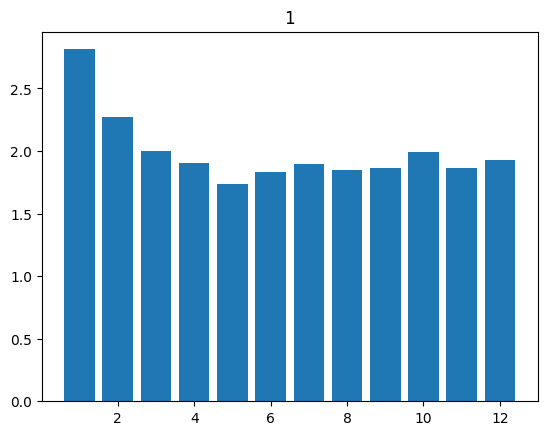

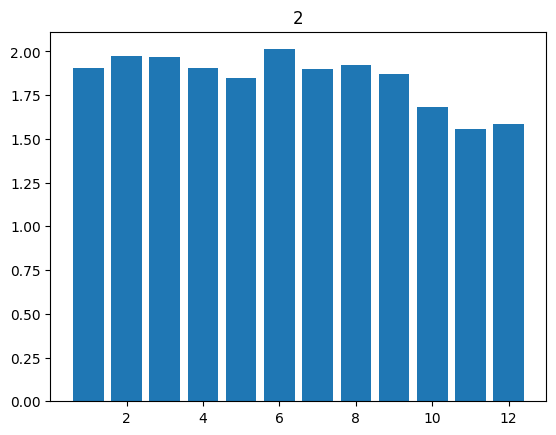

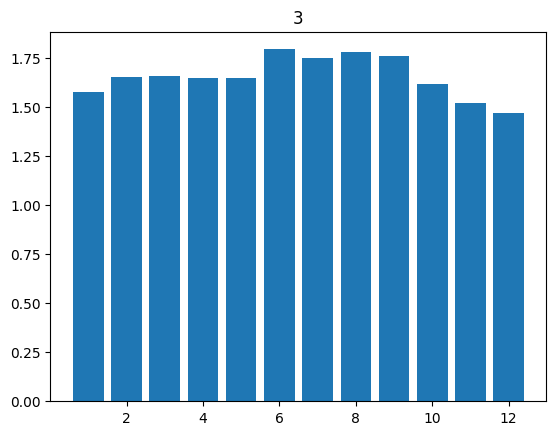

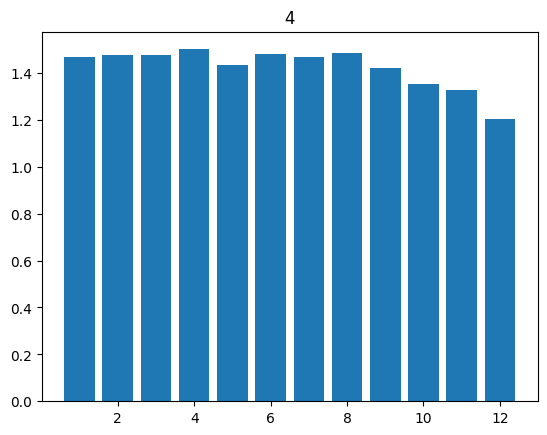

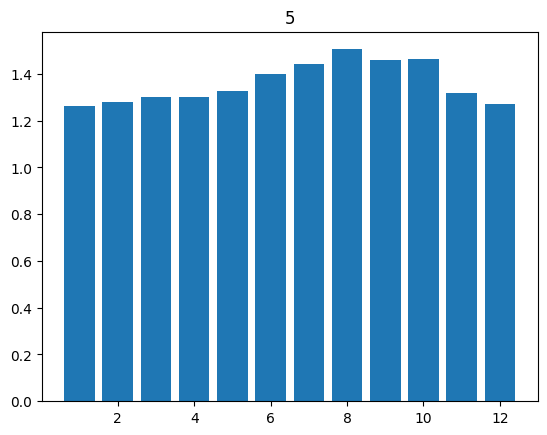

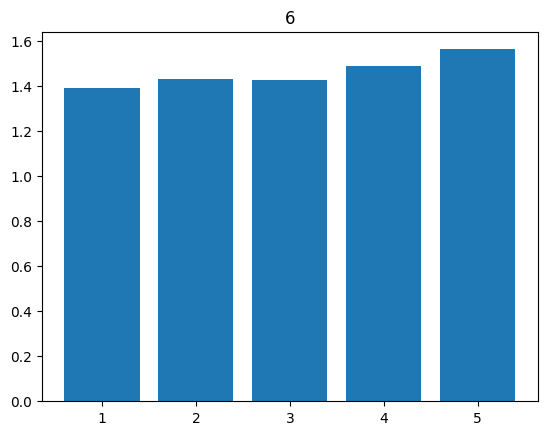

In [ ]:
x=sales.groupby(["month","store_id","year_enc"])["sales"].mean().unstack()
for i in sales["year_enc"].unique():
    plt.bar(x.index,x[i])
    plt.title(i)
    plt.show()
### NO UNIFORM CURVE SO MEAN ENCODING


In [ ]:
### THE ABOVE GRAPH TELL US THERE IS A GROWTH IN THE MOMENT OF SALES AROUND AUG-NOV AND DIPS AND LOWEST IN JAN AND FEB
### ALSO THERE IS AN UPWARD MOMENT OF SALES ACROSS YEARS AND SO AUG2015 SALES IS NOT SAME AS AUG 2016 SALES
sales["month_enc"]=sales.groupby("month")["sales"].transform("mean")
sales.drop("month",axis=1,inplace=True)

C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\2143338613.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales["month_enc"]=sales.groupby("month")["sales"].transform("mean")
C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\2143338613.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales.drop("month",axis=1,inplace=True)


In [ ]:
sales["dept_encoded"]=sales.groupby(["dept_id","store_id"])["sales"].transform("mean")
sales["cat_encoded"]=sales.groupby(["cat_id","store_id"])["sales"].transform("mean")
sales["store_id_encoded"]=sales.groupby("store_id")["sales"].transform("mean")

C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\899968558.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales["dept_encoded"]=sales.groupby(["dept_id","store_id"])["sales"].transform("mean")
C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\899968558.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales["dept_encoded"]=sales.groupby(["dept_id","store_id"])["sales"].transform("mean")
C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\899968558.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future vers

In [ ]:
print(sales.memory_usage(deep=True).sum() / 1024**2, "MB")

1752.6598176956177 MB


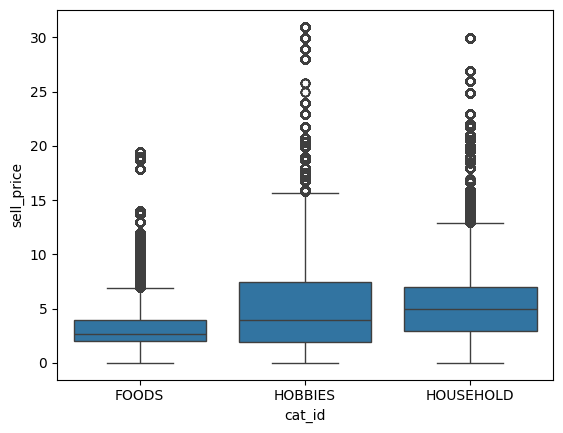

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=sales, x="cat_id", y="sell_price")
plt.show()
### WHY BOX PLOT IS THAT ITS IS EASY TO VIEW THE CLEAR DIFF IN THE SELL PRICES BASED ON ITEM ACROSS ALL THE STORES ACROSS AL THE WEEKS

### THIS PLOT SUGGEST THAT THERE IS AN RIGHT SKEWWED IN THE SELL PRICE DATA
### WE NEED AN FEATURE WHICH TELL ITEMS WITH SIMILAR PRICES IN THE SAME CATEGORY
### DIFFRENT CATEGORY HAVE DIFF PRICE RANGES ALSO SUUGESTS THAT THE RELATIVE PRICE SHOULD NOT BE CALUCLATED VIA THE GLOBAL AVG (CONSITING OF ALL ITEMS PRICES) INSTEAD IT SHOULD BE CALCULATED WRT ITEMS

C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\3120612217.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly_avg_prices = sales.groupby(['store_id', 'cat_id', 'wm_yr_wk'])['sell_price'].mean().reset_index()


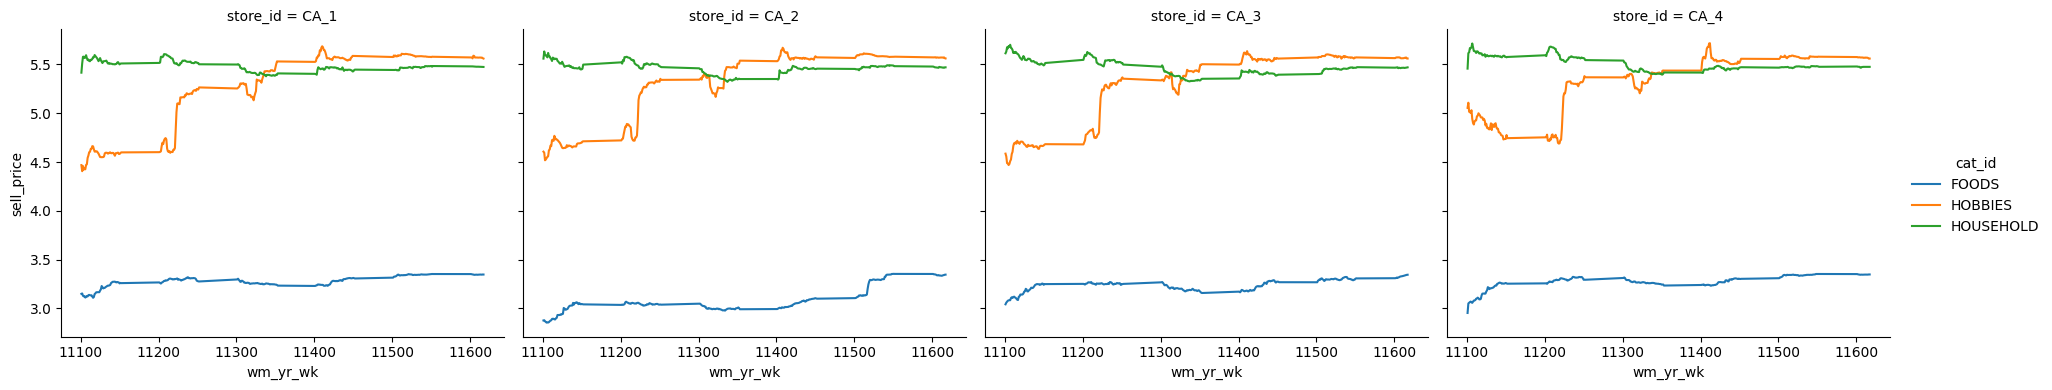

In [ ]:

weekly_avg_prices = sales.groupby(['store_id', 'cat_id', 'wm_yr_wk'])['sell_price'].mean().reset_index()
## THE PLOT IS BASED ON THE MEAN OF SELL PRICE GROUPED BY SOME ATTRIBUTES BCZ WHEN DONE PER ITEM THE COMPUTER CRASHES AS WE HAVE 3000+ items so we ASSUME THAT CATEGORY'mean PRICE MOMENT IS SIMILAR TO THE ITEMS'PRICE MOMENT

sns.relplot(
    data=weekly_avg_prices,
    x="wm_yr_wk",         # Time axis (weeks)
    y="sell_price",       # Average Price
    hue="cat_id",         # Different color line for each category
    col="store_id",       # Separate chart for each store
    col_wrap=4,           # Show 3 charts per row so it fits on screen
    kind="line",          # Use lines to show price trends over time
    height=4,
    aspect=1.2
)
### FOR THE BELOW GRAPH IT IS EVEDENT THAT THE PICE OF ITEMS (FOOD VERY UPWARD MOMENT MOSTLY STAYS NEAR MEAN and HOUSEHOLD LESS DOWNWARD MOMENT AND ALSO MOSTLY AROUND THE MEAN
#  BUT THE HOBBIES SHOW HUGE UPDAaRD MOMENT WITH LOT OF VARINCE CHANGE ALONG THE DIST)
## FROM THE GRAPH WE CAN CONCLUDE TO CREATE A FEATURE THAT IS LIKE PRICE MOMENTUN WITH less LAG

In [ ]:
len(sales["item_id"].unique()) ## THIS IS TOTAL NO.OF PRODUCTS

3049

In [ ]:
sales[sales["wm_yr_wk"]==11101].groupby(["cat_id"])["sell_price"].nunique()
### THE NO.OF unique price produts WITHIN SAME CATEGORY WHEN  NO ROUNDING OFF OF SALEPRICE AT WEEK 11101

C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\4021092653.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales[sales["wm_yr_wk"]==11101].groupby(["cat_id"])["sell_price"].nunique()


cat_id
FOODS        141
HOBBIES      125
HOUSEHOLD    154
Name: sell_price, dtype: int64

In [ ]:
# 1. Filter the dataset for just the week 11101
week_data = sales[sales["wm_yr_wk"] == 11101]

# 2. Round the prices, group by the category, and count unique values
item_price_counts = (
    week_data["sell_price"]
    .round(1)
    .groupby(week_data["cat_id"])
    .nunique()
)
## WHEN SELLPRICES ARE ROUNDED OFF FOR 1 digit THERE ARE LESS UNIQUE PRICE PRODUCTS SO WE CONSIDER A FEATURE no.oF UNIQUE ITEMS WITHIN SAME CATEGORY AT SIMILLAR PRICES AS AN NEW FEATURE
item_price_counts

C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\804827902.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(week_data["cat_id"])


cat_id
FOODS        70
HOBBIES      82
HOUSEHOLD    86
Name: sell_price, dtype: int64

In [ ]:
sales

,store_id,item_id,wm_yr_wk,sell_price,dept_id,cat_id,state_id,Date,sales,snap_CA,...,snap_WI,wday_enc,event_name_1_enc,event_name_2_enc,event_type_2_enc,year_enc,month_enc,dept_encoded,cat_encoded,store_id_encoded
7,CA_1,HOBBIES_1_008,11101,0.46,HOBBIES_1,HOBBIES,CA,d_1,12,0,...,0,2.057239,1.643192,1.635224,1.635224,1,1.490592,1.259480,1.003741,1.635717
8,CA_1,HOBBIES_1_009,11101,1.56,HOBBIES_1,HOBBIES,CA,d_1,2,0,...,0,2.057239,1.643192,1.635224,1.635224,1,1.490592,1.259480,1.003741,1.635717
9,CA_1,HOBBIES_1_010,11101,3.17,HOBBIES_1,HOBBIES,CA,d_1,0,0,...,0,2.057239,1.643192,1.635224,1.635224,1,1.490592,1.259480,1.003741,1.635717
11,CA_1,HOBBIES_1_012,11101,5.98,HOBBIES_1,HOBBIES,CA,d_1,0,0,...,0,2.057239,1.643192,1.635224,1.635224,1,1.490592,1.259480,1.003741,1.635717
14,CA_1,HOBBIES_1_015,11101,0.70,HOBBIES_1,HOBBIES,CA,d_1,4,0,...,0,2.057239,1.643192,1.635224,1.635224,1,1.490592,1.259480,1.003741,1.635717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23672431,CA_4,FOODS_3_823,11617,2.98,FOODS_3,FOODS,CA,d_1941,0,0,...,0,1.030477,0.902874,0.898891,0.898891,6,1.559225,1.564017,1.294094,0.898975
23672432,CA_4,FOODS_3_824,11617,2.48,FOODS_3,FOODS,CA,d_1941,0,0,...,0,1.030477,0.902874,0.898891,0.898891,6,1.559225,1.564017,1.294094,0.898975
23672433,CA_4,FOODS_3_825,11617,3.98,FOODS_3,FOODS,CA,d_1941,0,0,...,0,1.030477,0.902874,0.898891,0.898891,6,1.559225,1.564017,1.294094,0.898975
23672434,CA_4,FOODS_3_826,11617,1.28,FOODS_3,FOODS,CA,d_1941,4,0,...,0,1.030477,0.902874,0.898891,0.898891,6,1.559225,1.564017,1.294094,0.898975


In [ ]:
### RELEATIVE PRICE WRT TO HIGHEST PRICE OF THE PRODUCT  EVERY ITEMS PRICE IS NORMALIED WITH ITS HISTORY OF PRICES
maxprice=sales.groupby("item_id")["sell_price"].cummax()
maxprice

C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\413152104.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  maxprice=sales.groupby("item_id")["sell_price"].cummax()


7           0.46
8           1.56
9           3.17
11          5.98
14          0.70
            ... 
23672431    2.98
23672432    2.68
23672433    4.38
23672434    1.28
23672435    1.00
Name: sell_price, Length: 18559286, dtype: float32

In [ ]:
sales["rel_price"]=sales["sell_price"]/maxprice.values
sales["rel_price"]

C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\796508197.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales["rel_price"]=sales["sell_price"]/maxprice.values


7           1.000000
8           1.000000
9           1.000000
11          1.000000
14          1.000000
              ...   
23672431    1.000000
23672432    0.925373
23672433    0.908676
23672434    1.000000
23672435    1.000000
Name: rel_price, Length: 18559286, dtype: float32

In [ ]:
print(sales["sell_price"].var())
print(sales["sell_price"].max())
print(sales["sell_price"].min())

11.641859
30.98
0.01


In [ ]:
## ITEMS UNIQUE FEATURE WHICH IS THE NO.oF ITEMS THAT HAS SAME ITEMS IN SAME PRICES IN SAME CATEGORY AND WITHOUT CATEGORY
## WHY GROUPBY WM_YR_WK BCZ THE PRICE VARY WEEKLY
sales["price_bucket"]=sales["sell_price"].round(1)
 ##USED TO GROUP THE SIMILAR PRICES RATHER THAN CREATING EACH GROUP FOR SIMILAR PRICES THE SIMILARIY IS CONSIDERED AT 1 DIGIT PRECISON IN PRICE
sales["tot_items_by_cat"]=sales.groupby(["price_bucket","cat_id","wm_yr_wk"])["item_id"].transform("nunique")
sales["tot_items_by_price"]=sales.groupby(["price_bucket","store_id","wm_yr_wk"])["item_id"].transform("nunique")

C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\2982103324.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales["price_bucket"]=sales["sell_price"].round(1)
C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\2982103324.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales["tot_items_by_cat"]=sales.groupby(["price_bucket","cat_id","wm_yr_wk"])["item_id"].transform("nunique")
C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\2982103324.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_in

In [ ]:
print(len(sales["sell_price"].unique()))
print(len(sales["price_bucket"].unique()))
sales.drop(["dept_id","cat_id","price_bucket"],axis=1,inplace=True)

### THE BELOW VALUE SUGGEST THAT THERE IS AN HUGE DIFF WHEN WE GROUP SIMILAR PRICES AT 1 digit precison

746
182


C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\4026528452.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales.drop(["dept_id","cat_id","price_bucket"],axis=1,inplace=True)


In [ ]:
sales

,store_id,item_id,wm_yr_wk,sell_price,state_id,Date,sales,snap_CA,snap_TX,snap_WI,...,event_name_2_enc,event_type_2_enc,year_enc,month_enc,dept_encoded,cat_encoded,store_id_encoded,rel_price,tot_items_by_cat,tot_items_by_price
7,CA_1,HOBBIES_1_008,11101,0.46,CA,d_1,12,0,0,0,...,1.635224,1.635224,1,1.490592,1.259480,1.003741,1.635717,1.000000,23,21
8,CA_1,HOBBIES_1_009,11101,1.56,CA,d_1,2,0,0,0,...,1.635224,1.635224,1,1.490592,1.259480,1.003741,1.635717,1.000000,8,12
9,CA_1,HOBBIES_1_010,11101,3.17,CA,d_1,0,0,0,0,...,1.635224,1.635224,1,1.490592,1.259480,1.003741,1.635717,1.000000,5,30
11,CA_1,HOBBIES_1_012,11101,5.98,CA,d_1,0,0,0,0,...,1.635224,1.635224,1,1.490592,1.259480,1.003741,1.635717,1.000000,3,30
14,CA_1,HOBBIES_1_015,11101,0.70,CA,d_1,4,0,0,0,...,1.635224,1.635224,1,1.490592,1.259480,1.003741,1.635717,1.000000,9,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23672431,CA_4,FOODS_3_823,11617,2.98,CA,d_1941,0,0,0,0,...,0.898891,0.898891,6,1.559225,1.564017,1.294094,0.898975,1.000000,150,227
23672432,CA_4,FOODS_3_824,11617,2.48,CA,d_1941,0,0,0,0,...,0.898891,0.898891,6,1.559225,1.564017,1.294094,0.898975,0.925373,143,169
23672433,CA_4,FOODS_3_825,11617,3.98,CA,d_1941,0,0,0,0,...,0.898891,0.898891,6,1.559225,1.564017,1.294094,0.898975,0.908676,72,160
23672434,CA_4,FOODS_3_826,11617,1.28,CA,d_1941,4,0,0,0,...,0.898891,0.898891,6,1.559225,1.564017,1.294094,0.898975,1.000000,12,16


In [ ]:
lag1price=sales.groupby(["store_id","item_id"])["sell_price"].shift(1)
sales["price_momentum"]=(sales["sell_price"]-lag1price)
sales["price_momentum"].fillna(0,inplace=True)

C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\2406451307.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lag1price=sales.groupby(["store_id","item_id"])["sell_price"].shift(1)
C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\2406451307.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales["price_momentum"]=(sales["sell_price"]-lag1price)
C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\2406451307.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.py

In [ ]:
sales["price_momentum"].sum()

np.float32(1124.6401)

In [ ]:
sales

,store_id,item_id,wm_yr_wk,sell_price,state_id,Date,sales,snap_CA,snap_TX,snap_WI,...,event_type_2_enc,year_enc,month_enc,dept_encoded,cat_encoded,store_id_encoded,rel_price,tot_items_by_cat,tot_items_by_price,price_momentum
7,CA_1,HOBBIES_1_008,11101,0.46,CA,d_1,12,0,0,0,...,1.635224,1,1.490592,1.259480,1.003741,1.635717,1.000000,23,21,0.0
8,CA_1,HOBBIES_1_009,11101,1.56,CA,d_1,2,0,0,0,...,1.635224,1,1.490592,1.259480,1.003741,1.635717,1.000000,8,12,0.0
9,CA_1,HOBBIES_1_010,11101,3.17,CA,d_1,0,0,0,0,...,1.635224,1,1.490592,1.259480,1.003741,1.635717,1.000000,5,30,0.0
11,CA_1,HOBBIES_1_012,11101,5.98,CA,d_1,0,0,0,0,...,1.635224,1,1.490592,1.259480,1.003741,1.635717,1.000000,3,30,0.0
14,CA_1,HOBBIES_1_015,11101,0.70,CA,d_1,4,0,0,0,...,1.635224,1,1.490592,1.259480,1.003741,1.635717,1.000000,9,8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23672431,CA_4,FOODS_3_823,11617,2.98,CA,d_1941,0,0,0,0,...,0.898891,6,1.559225,1.564017,1.294094,0.898975,1.000000,150,227,0.0
23672432,CA_4,FOODS_3_824,11617,2.48,CA,d_1941,0,0,0,0,...,0.898891,6,1.559225,1.564017,1.294094,0.898975,0.925373,143,169,0.0
23672433,CA_4,FOODS_3_825,11617,3.98,CA,d_1941,0,0,0,0,...,0.898891,6,1.559225,1.564017,1.294094,0.898975,0.908676,72,160,0.0
23672434,CA_4,FOODS_3_826,11617,1.28,CA,d_1941,4,0,0,0,...,0.898891,6,1.559225,1.564017,1.294094,0.898975,1.000000,12,16,0.0


### THE BELOW CODES ARE THE ONLY CHANGES IN RECURSIVE CSV

In [ ]:
### INTRODUCING LAG FEATURES
for i in range(1,29):
    sales[f"lag_{i}"]=sales.groupby(["item_id","store_id"])["sales"].shift(i)

C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\420662836.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales[f"lag_{i}"]=sales.groupby(["item_id","store_id"])["sales"].shift(i)
C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\420662836.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales[f"lag_{i}"]=sales.groupby(["item_id","store_id"])["sales"].shift(i)
C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\420662836.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observ

In [ ]:
##ROLLING MEAN FEATURES
window=[7,15,30,60,180]
for i in window:
    sales[f"rolling_mean_{i}"]=sales.groupby(['item_id','store_id'])["lag_1"].transform(lambda x: x.rolling(i).mean())
    sales[f"rolling_std_{i}"]=sales.groupby(["item_id","store_id"])["lag_1"].transform(lambda x: x.rolling(i).std())
### THE DATA LEAKAGE  IS NOT POSSIBLE AS WE ONLY DO BASED ON PREVIOUS LAGS
sales

C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\418140956.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales[f"rolling_mean_{i}"]=sales.groupby(['item_id','store_id'])["lag_1"].transform(lambda x: x.rolling(i).mean())
C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\418140956.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales[f"rolling_mean_{i}"]=sales.groupby(['item_id','store_id'])["lag_1"].transform(lambda x: x.rolling(i).mean())
C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\418140956.py:5: FutureWarning: The default of observed=False is

,store_id,item_id,wm_yr_wk,sell_price,state_id,Date,sales,snap_CA,snap_TX,snap_WI,...,rolling_mean_7,rolling_std_7,rolling_mean_15,rolling_std_15,rolling_mean_30,rolling_std_30,rolling_mean_60,rolling_std_60,rolling_mean_180,rolling_std_180
7,CA_1,HOBBIES_1_008,11101,0.46,CA,d_1,12,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,CA_1,HOBBIES_1_009,11101,1.56,CA,d_1,2,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,CA_1,HOBBIES_1_010,11101,3.17,CA,d_1,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,CA_1,HOBBIES_1_012,11101,5.98,CA,d_1,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,CA_1,HOBBIES_1_015,11101,0.70,CA,d_1,4,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23672431,CA_4,FOODS_3_823,11617,2.98,CA,d_1941,0,0,0,0,...,1.428571,0.975900,1.333333,0.975900,1.366667,0.927857,0.916667,0.979306,0.738889,1.105415
23672432,CA_4,FOODS_3_824,11617,2.48,CA,d_1941,0,0,0,0,...,1.000000,1.527525,0.800000,1.207122,0.566667,0.935261,0.433333,0.789049,0.144444,0.497168
23672433,CA_4,FOODS_3_825,11617,3.98,CA,d_1941,0,0,0,0,...,1.000000,0.577350,0.933333,0.703732,0.833333,0.833908,0.683333,0.812856,0.611111,0.786683
23672434,CA_4,FOODS_3_826,11617,1.28,CA,d_1941,4,0,0,0,...,1.714286,0.755929,1.466667,0.990430,2.033333,1.731719,2.100000,1.782210,1.766667,1.688277


In [ ]:
sales.drop(["state_id","wm_yr_wk"],axis=1,inplace=True)

C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\2675859503.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales.drop(["state_id","wm_yr_wk"],axis=1,inplace=True)


In [ ]:
print(sales.memory_usage(deep=True).sum() / 1024**2, "MB")

7469.601781845093 MB


In [ ]:
for i in sales.columns:
    if sales[i].dtype=="int64":
        sales[i]=pd.to_numeric(sales[i],downcast="integer")
    elif sales[i].dtype=="float64":
        sales[i]=pd.to_numeric(sales[i],downcast="float")
    elif sales[i].dtype=='object':
            # convert to category IF it has repeated/limited values
            num_unique = sales[i].nunique()
            num_total = len(sales[i])
            if num_unique / num_total < 0.5:  # heuristic: repeats a lot
                sales[i] = sales[i].astype('category')
            #This matters especially for item_id (there are ~3,000 unique items but millions of rows) — as category,
            #each row just stores a small integer code instead of the full string repeated millions of times.


C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\2355736784.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales[i]=pd.to_numeric(sales[i],downcast="float")
C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\2355736784.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales[i]=pd.to_numeric(sales[i],downcast="float")
C:\Users\Shree\AppData\Local\Temp\ipykernel_3964\2355736784.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

In [ ]:
print(sales.memory_usage(deep=True).sum() / 1024**2, "MB")
# why deep==True bcz when kept false it return the meory of the pointer not the orginal size

3876.6003608703613 MB


In [ ]:
sales.to_csv("processed_train_RECURSIVE.csv")

In [ ]:
sales.dtypes

store_id              category
item_id               category
wm_yr_wk                 int16
sell_price             float32
state_id              category
Date                  category
sales                    int16
snap_CA                   int8
snap_TX                   int8
snap_WI                   int8
wday_enc               float32
event_name_1_enc       float32
event_name_2_enc       float32
year_enc              category
month_enc              float32
dept_encoded           float32
cat_encoded            float32
store_id_encoded       float32
rel_price              float32
tot_items_by_cat         int16
tot_items_by_price       int16
price_momentum         float32
lag_28                 float32
lag_29                 float32
lag_30                 float32
lag_31                 float32
lag_32                 float32
lag_33                 float32
lag_34                 float32
lag_35                 float32
lag_36                 float32
lag_37                 float32
lag_38  